# Individual Contribution Statement For Dan Anafi

This code sample is excerpted from a team final project for CIS 5450 (Big Data Analytics) at the University of Pennsylvania. My contributions included portions of the data loading and cleaning, and all exploratory data visualization/analysis and regression modeling through the PCA section. In this sample, my primary authored section begins with “Correlation Data Analysis” and ends just before “Ridge Regression.”

The GitHub link to this project is here: https://github.com/dzanafi/IDA-code-sample/blob/main/EV%20Analysis%20Final%20Project.ipynb


# Group Members

*   Dan Anafi
*   Palmer Pesta
*   Nikhil Gupta
*   Ken Huang

# Introduction

Throughout this notebook we will be analyzing what factors play the biggest role in electric vehicle sales. The factors we will be analyzing are the adjusted annual income, residential electric rates, amount of public chargers, and the cost of electric cars. Let's begin!

Data Sets being used:


*   [Full Electric Vehicle Dataset](https://www.kaggle.com/datasets/sahirmaharajj/electric-vehicle-population)
*   [US Electric Utility Rates](https://www.kaggle.com/datasets/williecosta/us-utility-rates-2021)
*   [Electric & Alternative Fuel Charging Stations](https://www.kaggle.com/datasets/saketpradhan/electric-and-alternative-fuel-charging-stations)
*   [Vehicle Registrations by Class and County](https://data.wa.gov/Transportation/Vehicle-Registrations-by-Class-and-County/hmzg-s6q4/about_data)
*   [Individual Income Tax Statistics](https://www.irs.gov/statistics/soi-tax-stats-individual-income-tax-statistics-2021-zip-code-data-soi-0)
*   [Washington Car Population](https://www.washington-demographics.com/samples/downloads/Washington_DemographicsByZipCode_sample.xlsx)




#Setup

In [ ]:
!pip install folium
!pip install pgeocode

import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from string import ascii_letters
import matplotlib.pyplot as plt
import datetime as dt
import requests
from lxml import html
import math
import json
import re
import os
import gdown
import folium
import pgeocode
import branca
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold


# Exploratory Data Analysis

## Data Extraction

### Electric Vehicle Population Data

This dataset comes from [kaggle](https://www.kaggle.com/datasets/sahirmaharajj/electric-vehicle-population) and contains data from 2024 of all Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs) that are currently registered through Washington State Department of Licensing (DOL).

Data Fields:

*   **VIN (1-10)**: The 1st 10 characters of each vehicle's Vehicle Identification Number (VIN). NOTE: This is why there are duplicates due to it being only the first 10 characters.
*   **County**: This is the geographic region of a state that a vehicle's owner is listed to reside within. Vehicles are registered in Washington.
*   **City**: The city in which the registered owner resides.
*   **State**: This is the geographic region of the country associated with the record.
*   **Postal Code**: The 5 digit zip code in which the registered owner resides.
*   **Model Year**: The model year of the vehicle, determined by decoding the Vehicle Identification Number (VIN).
*   **Make**: The manufacturer of the vehicle, determined by decoding the Vehicle Identification Number (VIN).
*   **Model**: The model of the vehicle, determined by decoding the Vehicle Identification Number (VIN).
*   **Electric Vehicle Type**: This distinguishes the vehicle as all electric or a plug-in hybrid.
*   **Clean Alternative Fuel Vehicle (CAFV) Eligibility**: This categorizes vehicle as Clean Alternative Fuel Vehicles (CAFVs) based on the fuel requirement and electric-only range
*   **Electric Range**: Describes how far a vehicle can travel purely on its electric charge.
*   **Base MSRP**: This is the lowest Manufacturer's Suggested Retail Price (MSRP) for any trim level of the model in question.
*   **Legislative District**: The specific section of Washington State that the vehicle's owner resides in, as represented in the state.
*   **DOL Vehicle ID**: Unique number assigned to each vehicle by Department of Licensing for identification purposes.
*   **Vehicle Location**: The center of the ZIP Code for the registered vehicle.
*   **Electric Utility**: This is the electric power retail service territories serving the address of the registered vehicle.
*   **2020 Census Tract**: The census tract identifier is a combination of the state, county, and census tract codes.

In [ ]:
# Download dataset
!!kaggle datasets download -d sahirmaharajj/electric-vehicle-population

['Dataset URL: https://www.kaggle.com/datasets/sahirmaharajj/electric-vehicle-population',
 'License(s): apache-2.0',
 'Downloading electric-vehicle-population.zip to /content',
 '',
 '  0% 0.00/5.67M [00:00<?, ?B/s]',
 '',
 '100% 5.67M/5.67M [00:00<00:00, 131MB/s]']

In [ ]:
# Unzip folder in Colab content folder
!unzip /content/electric-vehicle-population.zip
# csv name: Electric_Vehicle_Population_Data.csv
df_electric_vehicle_population = pd.read_csv('Electric_Vehicle_Population_Data.csv')
df_electric_vehicle_population.info()

Archive:  /content/electric-vehicle-population.zip
  inflating: Electric_Vehicle_Population_Data.csv  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177866 entries, 0 to 177865
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         177866 non-null  object 
 1   County                                             177861 non-null  object 
 2   City                                               177861 non-null  object 
 3   State                                              177866 non-null  object 
 4   Postal Code                                        177861 non-null  float64
 5   Model Year                                         177866 non-null  int64  
 6   Make                                               177866 non-null  object 
 7   Model                                              1

### Utility Rates Data

This dataset from [kaggle](https://www.kaggle.com/datasets/williecosta/us-utility-rates-2021) contains data from 2022 with information about electricity rate by zip code.

Data Fields:

*   **zip**: The zip code
*   **eiaid**: Unique Identifier
*   **utility_name**: Name of the utility company
*   **state**: The US state served by utility
*   **service_type**: Electric service type (eg: bundled or delivery)
*   **ownership**: Who owns the electric company
*   **comm_rate**: Commerial KWH rate
*   **ind_rate**: Industrial rate
*   **res_rate**: Residential rate
*   **iou**: Whether the company is investor owned



In [ ]:
# Download dataset
!!kaggle datasets download -d williecosta/us-utility-rates-2021

['Dataset URL: https://www.kaggle.com/datasets/williecosta/us-utility-rates-2021',
 'License(s): Attribution 4.0 International (CC BY 4.0)',
 'Downloading us-utility-rates-2021.zip to /content',
 '',
 '  0% 0.00/324k [00:00<?, ?B/s]',
 '',
 '100% 324k/324k [00:00<00:00, 66.4MB/s]']

In [ ]:
# Unzip folder in Colab content folder
!unzip /content/us-utility-rates-2021.zip
# csv name: energy2021.csv
df_electricity_rates = pd.read_csv('energy2021.csv')
df_electricity_rates.info()

Archive:  /content/us-utility-rates-2021.zip
  inflating: energy2021.csv          
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80234 entries, 0 to 80233
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   zip           80234 non-null  int64  
 1   eiaid         80234 non-null  int64  
 2   utility_name  80234 non-null  object 
 3   state         80234 non-null  object 
 4   service_type  80234 non-null  object 
 5   ownership     80234 non-null  object 
 6   comm_rate     80234 non-null  float64
 7   ind_rate      80234 non-null  float64
 8   res_rate      80234 non-null  float64
 9   iou           80234 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 6.1+ MB


### Location of Chargers Data

This dataset from [kaggle](https://www.kaggle.com/datasets/saketpradhan/electric-and-alternative-fuel-charging-stations) contains the locations of all charging stations in the US and Canada during 2023.

Data Fields:

*   **Fuel Type Code**
*   **Station Name**
*   **Street Address**
*   **Intersection Directions**
*   **City**
*   **State**
*   **ZIP**
*   **Plus4**
*   **Station Phone**
*   **Status Code**
*   **Expected Date**
*   **Groups With Access Code**
*   **Access Days Time**
*   **Cards Accepted**
*   **BD Blends**
*   **NG Fill Type Code**
*   **NG PSI**
*   **EV Level1 EVSE Num**
*   **EV Level2 EVSE Num**
*   **EV DC Fast Count**
*   **EV Other Info**
*   **EV Network**
*   **EV Network Web**
*   **Geocode Status**
*   **Latitude**
*   **Longitude**
*   **Date Last Confirmed**
*   **ID**
*   **Updated At**
*   **Owner Type Code**
*   **Federal Agency ID**
*   **Federal Agency Name**
*   **Open Date**
*   **Hydrogen Status Link**
*   **NG Vehicle Class**
*   **LPG Primary**
*   **E85 Blender Pump**
*   **EV Connector Types**
*   **Country**
*   **Intersection Directions (French)**
*   **Access Days Time (French)**
*   **BD Blends (French)**
*   **Groups With Access Code (French)**
*   **Hydrogen Is Retail**
*   **Access Code**
*   **Access Detail Code**
*   **Federal Agency Code**
*   **Facility Type**
*   **CNG Dispenser Num**
*   **CNG On-Site Renewable Source**
*   **CNG Total Compression Capacity**
*   **CNG Storage Capacity**
*   **LNG On-Site Renewable Source**
*   **E85 Other Ethanol Blends**
*   **EV Pricing**
*   **EV Pricing (French)**
*   **LPG Nozzle Types**
*   **Hydrogen Pressures**
*   **Hydrogen Standards**
*   **CNG Fill Type Code**
*   **CNG PSI**
*   **CNG Vehicle Class**
*   **LNG Vehicle Class**
*   **EV On-Site Renewable Source**
*   **Restricted Access**

In [ ]:
# Download dataset
!!kaggle datasets download -d saketpradhan/electric-and-alternative-fuel-charging-stations

['Dataset URL: https://www.kaggle.com/datasets/saketpradhan/electric-and-alternative-fuel-charging-stations',
 'License(s): CC0-1.0',
 'Downloading electric-and-alternative-fuel-charging-stations.zip to /content',
 '',
 '  0% 0.00/4.48M [00:00<?, ?B/s]',
 '',
 '100% 4.48M/4.48M [00:00<00:00, 54.9MB/s]']

In [ ]:
# Unzip folder in Colab content folder
!unzip /content/electric-and-alternative-fuel-charging-stations
# csv name: Electric and Alternative Fuel Charging Stations.csv
charging_stations_df = pd.read_csv('Electric and Alternative Fuel Charging Stations.csv')
charging_stations_df.info()

Archive:  /content/electric-and-alternative-fuel-charging-stations.zip
  inflating: Charging Station Distribution US and Canada.png  
  inflating: Electric and Alternative Fuel Charging Station Counts by State.pdf  
  inflating: Electric and Alternative Fuel Charging Stations.csv  
  inflating: Historical Station Counts by State 2007-2021.xlsx  


<ipython-input-7-add06a1ee79d>:4: DtypeWarning: Columns (6,16,20,31,33,36,39,40,41,43,46,52,53,55,57,58,60,62) have mixed types. Specify dtype option on import or set low_memory=False.
  charging_stations_df = pd.read_csv('Electric and Alternative Fuel Charging Stations.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70406 entries, 0 to 70405
Data columns (total 65 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Fuel Type Code                    70406 non-null  object 
 1   Station Name                      70406 non-null  object 
 2   Street Address                    70405 non-null  object 
 3   Intersection Directions           4492 non-null   object 
 4   City                              70406 non-null  object 
 5   State                             70406 non-null  object 
 6   ZIP                               70405 non-null  object 
 7   Plus4                             0 non-null      float64
 8   Station Phone                     65204 non-null  object 
 9   Status Code                       70406 non-null  object 
 10  Expected Date                     1218 non-null   object 
 11  Groups With Access Code           70406 non-null  object 
 12  Acce

### Car Population in Washington Data

This data set from the [state of washington](https://data.wa.gov/Transportation/Vehicle-Registrations-by-Class-and-County/hmzg-s6q4/about_data) contains the data of all vechicle registration. **Note:** This data contains vehicles of all types including gas vehicles.

Car Population Data Fields:

*   **Fiscal Year**: This represents the 12 consecutive months beginning July 1st and ending June 30th, and is named for the calendar year in that it ends in. For example, July 1, 2023, through June 30, 2024, is fiscal year 2024. This aligns with the State of Washington's fiscal year.
*   **Transaction Date**: The time the transaction occured
*   **Transaction County**: This is the geographic region of the state associated with the vehicle licensing office where the transaction was processed. If the transaction was not processed by a vehicle licensing office, the county shows as ‘Department of Licensing – HQ’ (where HQ equals Headquarters).
*   **Residential County**: This is the geographic region of the state associated with the record. These addresses may be located in other states.
*   **Fuel Type**: This is the source of power that is most often used to propel a vehicle.
*   **Primary Use Class**: This describes the intended use as defined by WAC 308-96A-099. This is sometimes referred to as ‘use class’.
*   **Counts**: This represents the number of records in each grouping.

In [ ]:
overall_car_population_db = pd.read_csv('https://data.wa.gov/api/views/hmzg-s6q4/rows.csv?date=20241115&accessType=DOWNLOAD')
overall_car_population_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 739707 entries, 0 to 739706
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   Fiscal Year         739707 non-null  int64 
 1   Transaction Date    739707 non-null  object
 2   Transaction County  739707 non-null  object
 3   Residential County  739707 non-null  object
 4   Fuel Type           739707 non-null  object
 5   Primary Use Class   739707 non-null  object
 6   Counts              739707 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 39.5+ MB


### Average Gross Income By Zipcode

This dataset from [the IRS](https://www.irs.gov/statistics/soi-tax-stats-individual-income-tax-statistics-2021-zip-code-data-soi-0) provides income data from 2013 by zip code. 167 columns, see pdf for explanation.

In [ ]:
gross_income_url = 'https://www.irs.gov/pub/irs-soi/21zpallagi.csv'
income_df = pd.read_csv(gross_income_url)
income_df.columns

Index(['STATEFIPS', 'STATE', 'zipcode', 'agi_stub', 'N1', 'mars1', 'MARS2',
       'MARS4', 'ELF', 'CPREP',
       ...
       'N85300', 'A85300', 'N11901', 'A11901', 'N11900', 'A11900', 'N11902',
       'A11902', 'N12000', 'A12000'],
      dtype='object', length=167)

### Population Data

Data from [Washington Demographics](https://www.washington-demographics.com/samples/downloads/Washington_DemographicsByZipCode_sample.xlsx)

In [ ]:
import requests
from io import BytesIO

population_data_url = 'https://www.washington-demographics.com/samples/downloads/Washington_DemographicsByZipCode_sample.xlsx'
response = requests.get(population_data_url)
response.raise_for_status()
population_df = pd.read_excel(BytesIO(response.content), sheet_name='2022AmericanCommunitySurvey')
population_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 67 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Geography                      607 non-null    object
 1   State                          607 non-null    object
 2   County                         3 non-null      object
 3   City                           3 non-null      object
 4   Population                     608 non-null    object
 5   Unnamed: 5                     608 non-null    object
 6   Unnamed: 6                     5 non-null      object
 7   Median Household Income        4 non-null      object
 8   Household Income Distribution  5 non-null      object
 9   Unnamed: 9                     5 non-null      object
 10  Unnamed: 10                    5 non-null      object
 11  Unnamed: 11                    5 non-null      object
 12  Unnamed: 12                    5 non-null      object
 13  Unnam

### MSRP of Purchased Cars


Manually entered and researched dataset that provides MSRP of electric cars.

Note: Quantity of cars purchased is greater than 100. MSRP's extracted from the newest model and assume the base trim is chosen.

Data Fields:

*   **make**: The make of the vehicle
*   **model**: The model of the vehicle
*   **msrp**: The MSRP of the base trim model of the most recent year

In [ ]:
msrp_df = pd.DataFrame({
    'make': ['TESLA', 'TESLA', 'NISSAN', 'TESLA', 'CHEVROLET', 'TESLA', 'CHEVROLET', 'VOLKSWAGEN', 'JEEP', 'FORD', 'KIA', 'CHRYSLER', 'TOYOTA', 'HYUNDAI', 'BMW', 'TOYOTA',
             'KIA', 'RIVIAN', 'FORD', 'CHEVROLET', 'RIVIAN', 'FORD', 'FORD', 'VOLVO', 'AUDI', 'JEEP', 'VOLVO', 'VOLKSWAGEN', 'BMW', 'VOLVO', 'TOYOTA', 'MITSUBISHI', 'POLESTAR',
             'HONDA', 'BMW', 'FIAT', 'SUBARU', 'HYUNDAI', 'AUDI', 'MINI', 'PORSCHE', 'NISSAN', 'KIA', 'KIA', 'DODGE', 'AUDI', 'AUDI', 'RIVIAN', 'MAZDA', 'BMW', 'VOLVO', 'BMW', 'KIA',
             'FORD', 'PORSCHE', 'FORD', 'MERCEDES-BENZ', 'HYUNDAI', 'BMW', 'CADILLAC', 'AUDI', 'MERCEDES-BENZ', 'TOYOTA', 'CHEVROLET', 'LUCID', 'HYUNDAI', 'FORD', 'JAGUAR',
             'MERCEDES-BENZ', 'MINI', 'HYUNDAI', 'KIA', 'HYUNDAI', 'MERCEDES-BENZ', 'MERCEDES-BENZ', 'KIA', 'HYUNDAI', 'LEXUS', 'AUDI', 'LEXUS', 'LINCOIN', 'SMART', 'VOLVO',
             'GENESIS', 'AUDI', 'AUDI', 'PORSCHE', 'MERCEDES-BENZ', 'MERCEDES-BENZ', 'KIA'],

    'model': ['MODEL Y', 'MODEL 3', 'LEAF', 'MODEL S', 'BOLT EV', 'MODEL X', 'VOLT', 'ID.4', 'WRANGLER', 'MUSTANG MACH-E', 'NIRO', 'PACIFICA', 'PRIUS PRIME', 'IONIQ 5', 'X5', 'RAV4 PRIME',
              'EV6', 'R1S', 'FUSION', 'BOLT EUV', 'R1T', 'F-150', 'C-MAX', 'XC90', 'E-TRON', 'GRAND CHEROKEE', 'XC60', 'E-GOLF', 'I4', 'XC40', 'PRIUS PLUG-IN', 'OUTLANDER',
              'PS2', 'CLARITY', 'IX', '500', 'SOLTERRA', 'KONA ELECTRIC', 'Q5 E', 'HARDTOP', 'TAYCAN', 'ARIYA', 'SORENTO', 'SPORTAGE', 'HORNET', 'A3', 'Q4', 'EDV', 'CX-90',
              '330E', 'C40', '530E', 'SOUL', 'ESCAPE', 'CAYENNE', 'TRANSIT', 'EQB-CLASS', 'IONIQ 6', 'X3', 'LYRIQ', 'Q8', 'EQE-CLASS SUV', 'BZ4X', 'SPARK', 'AIR', 'IONIQ', 'FOCUS', 'I-PACE',
              'EQS-CLASS SUV', 'COUNTRYMAN', 'KONA', 'SOUL EV', 'SANTA FE', 'EQS-CLASS SEDAN', 'GLC-CLASS', 'EV9', 'TUCSON', 'NX', 'E-TRON SPORTBACK', 'RZ 450E', 'AVIATOR', 'FORTWO ELECTRIC DRIVE',
              'S60', 'GV60', 'Q5', 'E-TRON GT', 'PANAMERA', 'GLE-CLASS', 'EQE-CLASS SEDAN', 'OPTIMA'],

    'msrp': [43990, 38990, 28140, 74990, 26500, 79900, 34395, 41160, 50695, 39995, 26940, 52495, 32975, 66100, 66875, 43690, 42600, 75900, 28000, 27800, 69900, 54995,
             24995, 57400, 74800, 38035, 47050, 32790, 52800, 40650, 32975, 40445, 6480, 34415, 87250, 32500, 44995, 32875, 58500, 30900, 99400, 39590, 31990, 27190,
             41645, 35800, 49800, 86325, 37845, 45600, 54895, 57600, 35000, 35615, 84700, 53095, 53050, 37500, 49500, 57195, 74400, 74900, 43070, 25120, 69900,
             23600, 29120, 72000, 104400, 32650, 24350, 35000, 36950, 104400, 49250, 56395, 28605, 4199, 71995, 43975, 53340, 23900, 42600, 52000, 45400, 106500, 115500,
             62650, 74900, 26990]
})
msrp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   make    90 non-null     object
 1   model   90 non-null     object
 2   msrp    90 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 2.2+ KB


## Data Cleaning

### Electric Vehicle Population

**Data Fields:**

*   **car_unique_identifier**: The number assigned to each unique car in the dataframe.
*   **vin**: The vehicle identification number
*   **county**: The county the Vin is registered to
*   **zip_code**: The 5 digit zip code in which the registered owner resides.*
*   **model_year**: The model year of the vehicle, determined by decoding the Vehicle Identification Number (VIN).*
*   **make**: The manufacturer of the vehicle, determined by decoding the Vehicle Identification Number (VIN).*
*   **model**: The model of the vehicle, determined by decoding the Vehicle Identification Number (VIN).*
*   **electric_vehicle_type**: This distinguishes the vehicle as all electric or a plug-in hybrid.*
*   **cafv_eligibility**: This categorizes vehicle as Clean Alternative Fuel Vehicles (CAFVs) based on the fuel requirement and electric-only range.*
*   **electric_range**: Describes how far a vehicle can travel purely on its electric charge.*

[* From Kaggle](https://www.kaggle.com/datasets/sahirmaharajj/electric-vehicle-population)



In [ ]:
df_electric_vehicle_population_cleaned = df_electric_vehicle_population[df_electric_vehicle_population['State'] == 'WA']
# Drop unneeded columns
df_electric_vehicle_population_cleaned = df_electric_vehicle_population_cleaned.drop(columns=['VIN (1-10)', 'State', 'City', 'Base MSRP', 'Legislative District', 'DOL Vehicle ID', 'Vehicle Location', 'Electric Utility', '2020 Census Tract']).dropna().reset_index(drop=True)
# Create a unique identifier for each car
df_electric_vehicle_population_cleaned = df_electric_vehicle_population_cleaned.reset_index()
# Rename the columns
df_electric_vehicle_population_cleaned = df_electric_vehicle_population_cleaned.rename(columns={'index': 'car_unique_identifier', 'County': 'county', 'Postal Code': 'zip_code', 'Model Year': 'model_year', 'Make': 'make', 'Model': 'model', 'Electric Vehicle Type': 'electric_vehicle_type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility': 'cafv_eligibility', 'Electric Range': 'electric_range'})
# # Make sure that data types/entries are consistant
df_electric_vehicle_population_cleaned['zip_code'] = df_electric_vehicle_population_cleaned['zip_code'].astype('int64')
df_electric_vehicle_population_cleaned['county'] = df_electric_vehicle_population_cleaned['county'].str.lower()
df_electric_vehicle_population_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177477 entries, 0 to 177476
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   car_unique_identifier  177477 non-null  int64 
 1   county                 177477 non-null  object
 2   zip_code               177477 non-null  int64 
 3   model_year             177477 non-null  int64 
 4   make                   177477 non-null  object
 5   model                  177477 non-null  object
 6   electric_vehicle_type  177477 non-null  object
 7   cafv_eligibility       177477 non-null  object
 8   electric_range         177477 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 12.2+ MB


### Electricity Rates

**Data Fields:**


*   **zip_code**: The zip code of the electricity rate.
*   **residential_electricity_rate**: The cost of residential electricity in the zip code listed.

In [ ]:
df_electricity_rates_cleaned = df_electricity_rates[df_electricity_rates['state'] == 'WA'].drop(columns=['eiaid', 'state', 'comm_rate', 'ind_rate', 'ownership', 'service_type', 'iou', 'utility_name']).dropna()
df_electricity_rates_cleaned = df_electricity_rates_cleaned.groupby(by=['zip']).mean().dropna().reset_index()
df_electricity_rates_cleaned = df_electricity_rates_cleaned.rename(columns={'res_rate': 'residential_electricity_rate', 'zip': 'zip_code'})
df_electricity_rates_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Data columns (total 2 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   zip_code                      696 non-null    int64  
 1   residential_electricity_rate  696 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 11.0 KB


### Location of Chargers

**Data Fields:**

*   **zip_code**: The zip code of the charging station.
*   **number_of_charging_stations**: The number of charging stations within the zip code.

In [ ]:
charging_stations_cleaned = charging_stations_df[(charging_stations_df['Fuel Type Code'] == 'ELEC') & (charging_stations_df['State'] == 'WA')]
charging_stations_cleaned = charging_stations_cleaned[['ID', 'ZIP', 'EV Connector Types', 'EV Network', 'Restricted Access']].reset_index(drop=True)
charging_stations_cleaned = charging_stations_cleaned.rename(columns={'ID': 'id', 'ZIP': 'zip_code', 'EV Connector Types': 'ev_connector_types', 'EV Network': 'ev_network', 'Restricted Access': 'restricted_access'})
charging_stations_cleaned['zip_code'] = charging_stations_cleaned['zip_code'].astype('int64')
charging_stations_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  1800 non-null   int64 
 1   zip_code            1800 non-null   int64 
 2   ev_connector_types  1797 non-null   object
 3   ev_network          1800 non-null   object
 4   restricted_access   1177 non-null   object
dtypes: int64(2), object(3)
memory usage: 70.4+ KB


In [ ]:
number_of_charging_stations = charging_stations_cleaned.groupby(by=['zip_code']).count().reset_index()
number_of_charging_stations = number_of_charging_stations.rename(columns={'id': 'number_of_charging_stations'})[['zip_code', 'number_of_charging_stations']].sort_values(by=['number_of_charging_stations'], ascending=False).reset_index(drop=True)
number_of_charging_stations

,zip_code,number_of_charging_stations
0,98004,105
1,98109,80
2,98121,68
3,98005,48
4,98104,43
...,...,...
288,98126,1
289,98513,1
290,98509,1
291,98146,1


### Total Car Population (Gas, Hybrid, and Electric)

**Data Fields:**

*   **county**: The county in WA
*   **number_of_cars_in_county**: The total number of cars in the county

In [ ]:
overall_car_population_db_cleaned = overall_car_population_db[overall_car_population_db['Fiscal Year'] == 2021].drop(columns=['Transaction County', 'Fiscal Year', 'Transaction Date', 'Counts', 'Primary Use Class']).reset_index(drop=True)
overall_car_population_db_cleaned = overall_car_population_db_cleaned.rename(columns={'Residential County': 'county'})
overall_car_population_db_cleaned = overall_car_population_db_cleaned[overall_car_population_db_cleaned['county'] != 'Out Of State']
overall_car_population_db_cleaned['county'] = overall_car_population_db_cleaned['county'].str.lower()
overall_car_population_db_cleaned = overall_car_population_db_cleaned.reset_index(drop=True)
overall_car_population_db_cleaned = overall_car_population_db_cleaned.groupby(by=['county']).count().reset_index().rename(columns={'Fuel Type': 'number_of_cars_in_county'})
overall_car_population_db_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   county                    39 non-null     object
 1   number_of_cars_in_county  39 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 752.0+ bytes


### Gross Income

**Data Fields:**


*   **zip_code**: The zip code of the tax filers
*   **adjust_gross_income**: The adjusted gross income of the zip code
*   **number_of_returns_with_taxable_income**: The number of returns with taxable income in the zip code

In [ ]:
income_cleaned = income_df[(income_df['STATE'] == 'WA') & (income_df['zipcode'] != 0) & (income_df['zipcode'] != 99999)][['zipcode', 'A00100', 'N04800']]
income_cleaned = income_cleaned.rename(columns={'zipcode': 'zip_code', 'A00100': 'adjust_gross_income', 'N04800': 'number_of_returns_with_taxable_income'}).reset_index(drop=True)
income_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2988 entries, 0 to 2987
Data columns (total 3 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   zip_code                               2988 non-null   int64  
 1   adjust_gross_income                    2988 non-null   float64
 2   number_of_returns_with_taxable_income  2988 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 70.2 KB


In [ ]:
income_grouped_zip = income_cleaned.groupby(by=['zip_code']).mean().reset_index()
income_grouped_zip['adjust_gross_income'] = income_grouped_zip['adjust_gross_income'].astype(int)
income_grouped_zip['number_of_returns_with_taxable_income'] = income_grouped_zip['number_of_returns_with_taxable_income'].astype(int)
income_grouped_zip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 3 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   zip_code                               498 non-null    int64
 1   adjust_gross_income                    498 non-null    int64
 2   number_of_returns_with_taxable_income  498 non-null    int64
dtypes: int64(3)
memory usage: 11.8 KB


### Population of Washington State

**Data Fields:**


*   **zip_code**: Zip codes in Washington
*   **population_of_zip_code**: The number of people within the zip code

In [ ]:
population_cleaned_df = population_df[population_df['State'] == 'Washington'].reset_index(drop=True)
population_cleaned_df = population_cleaned_df[~population_cleaned_df['Geography'].str.contains('[a-zA-Z]', na=False)]
population_cleaned_df = population_cleaned_df[['Geography', 'Unnamed: 5']]
population_cleaned_df = population_cleaned_df.rename(columns={'Geography': 'zip_code', 'Unnamed: 5': 'population_of_zip_code'})
population_cleaned_df['zip_code'] = population_cleaned_df['zip_code'].astype(int)
population_cleaned_df['population_of_zip_code'] = population_cleaned_df['population_of_zip_code'].astype(int)
population_cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 605 entries, 1 to 605
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   zip_code                605 non-null    int64
 1   population_of_zip_code  605 non-null    int64
dtypes: int64(2)
memory usage: 14.2 KB


## Final Data Processing & Combination

### Combining the Data

**Data Fields:**


*   **zip_code**: The zipcode of the data available.
*   **model_year**: The model of the vehicle, determined by decoding the Vehicle Identification Number (VIN).*
*   **make**: The manufacturer of the vehicle, determined by decoding the Vehicle Identification Number (VIN).*
*   **model**: The model year of the vehicle, determined by decoding the Vehicle Identification Number (VIN).*
*   **electric_vehicle_type**: This distinguishes the vehicle as all electric or a plug-in hybrid.*
*   **cafv_eligibility**: This categorizes vehicle as Clean Alternative Fuel Vehicles (CAFVs) based on the fuel requirement and electric-only range.*
*   **electric_range**: Describes how far a vehicle can travel purely on its electric charge.*
*   **residential_electricity_rate**: The residential electricity rate for the zip code.
*   **number_of_charging_stations**: The number of charging stations that can be found within the zip code.
*   **adjust_gross_income**: The adjusted gross income within a given zip code.
*   **number_of_returns_with_taxable_income**: The number of returns filed in a zip code with taxable income.
*   **msrp**: The purchase price of the latest make and model of a car disregarding the year of the model.
*   **county**: The county which the zip code is found. Has an 80% accuracy due to some zip codes falling in multiple counties.
*   **number_of_cars_in_county**: Total number of gas, hybrid, and electric vehicles in the zip code.
* **population_of_zip_code**: The population of the zip code


*[From Kaggle](https://www.kaggle.com/datasets/sahirmaharajj/electric-vehicle-population)

In [ ]:
# Merging The electic populations and the electricity rates by zip code
merge1 = df_electric_vehicle_population_cleaned.merge(df_electricity_rates_cleaned, on=['zip_code'])
# Merging the previous df with the number of charging stations and filling na's with 0
merge2 = merge1.merge(number_of_charging_stations, on=['zip_code'], how='left')
merge2['number_of_charging_stations'] = merge2['number_of_charging_stations'].fillna(0)
# Merging the previous df with the gross income by zip code
merge3 = merge2.merge(income_grouped_zip, on=['zip_code'])
# Merging the previous df with the MSRP of the purchased vehicle by zip code
merge4 = merge3.merge(msrp_df, on=['make', 'model'])
# Merging the previous df with the population data
merge5 = merge4.merge(population_cleaned_df, on=['zip_code'])
# Merging the previous df with the matching about of cars in the county
combined_electric_vehicle_df = merge5.merge(overall_car_population_db_cleaned, on=['county'])
combined_electric_vehicle_df

,car_unique_identifier,county,zip_code,model_year,make,model,electric_vehicle_type,cafv_eligibility,electric_range,residential_electricity_rate,number_of_charging_stations,adjust_gross_income,number_of_returns_with_taxable_income,msrp,population_of_zip_code,number_of_cars_in_county
0,0,king,98122,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,0.077788,12.0,595680,3603,43990,41268,5934
1,1,snohomish,98021,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0.072084,3.0,472568,2320,43990,34993,4717
2,2,king,98109,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270,0.118519,80.0,658152,3188,74990,32251,5934
3,3,king,98027,2016,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210,0.057423,14.0,512520,2260,74990,27915,5934
4,4,kitsap,98392,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0.057423,1.0,20504,223,43990,3203,3279
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173566,177472,pierce,98391,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0.057423,1.0,542987,4121,43990,56646,4961
173567,177473,mason,98584,2023,HYUNDAI,KONA ELECTRIC,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0.087763,3.0,202760,2405,32875,38615,2509
173568,177474,grant,98848,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0.043717,3.0,72216,978,43990,12959,3590
173569,177475,king,98010,2021,VOLKSWAGEN,ID.4,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0.057423,0.0,97024,588,41160,6128,5934


### Correlation Data Analysis

Processing the combined data for the number of electric vehicles and the correlation between fields.

In [ ]:
# get total number of electric vehicles per zip code
electric_vehicles_by_zip = df_electric_vehicle_population_cleaned.groupby('zip_code')['car_unique_identifier'].count().reset_index(name='number_of_electric_vehicles_by_zip')

# get total number of each electric vehicle type per zip code
ev_type_counts = df_electric_vehicle_population_cleaned.groupby(['zip_code', 'electric_vehicle_type'])['model'].count().reset_index(name='ev_type_count')

ev_type_counts_pivot = ev_type_counts.pivot(index='zip_code', columns='electric_vehicle_type', values='ev_type_count').reset_index()

# merge two together
combined_ev_counts = electric_vehicles_by_zip.merge(ev_type_counts_pivot, on='zip_code').fillna(0)

# replace spaces in column names for ease
combined_ev_counts = combined_ev_counts.rename(columns=lambda x: x.replace(" ", "_").replace("(", "").replace(")", ""))

# merge with combined_electric_vehicle_df to look for correlations
correlation_df = combined_ev_counts.merge(combined_electric_vehicle_df, on='zip_code')

# select subset for mapping
mapping_df = correlation_df[['zip_code', 'number_of_electric_vehicles_by_zip', 'Battery_Electric_Vehicle_BEV', 'Plug-in_Hybrid_Electric_Vehicle_PHEV', 'number_of_charging_stations', 'population_of_zip_code']].drop_duplicates()

# select subset for pairplot
pairplot_df = correlation_df[['zip_code', 'number_of_electric_vehicles_by_zip', 'Battery_Electric_Vehicle_BEV', 'Plug-in_Hybrid_Electric_Vehicle_PHEV', 'adjust_gross_income', 'residential_electricity_rate', 'number_of_charging_stations', 'population_of_zip_code']].drop_duplicates()

correlation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173571 entries, 0 to 173570
Data columns (total 19 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   zip_code                               173571 non-null  int64  
 1   number_of_electric_vehicles_by_zip     173571 non-null  int64  
 2   Battery_Electric_Vehicle_BEV           173571 non-null  float64
 3   Plug-in_Hybrid_Electric_Vehicle_PHEV   173571 non-null  float64
 4   car_unique_identifier                  173571 non-null  int64  
 5   county                                 173571 non-null  object 
 6   model_year                             173571 non-null  int64  
 7   make                                   173571 non-null  object 
 8   model                                  173571 non-null  object 
 9   electric_vehicle_type                  173571 non-null  object 
 10  cafv_eligibility                       173571 non-null  

## EDA Visualization

### Washington Population Map

The state of washington with the number of electric chargers, populations, and number of electric vehicles.

* Blue = Charging Stations
* Red = Number of Electric Vehicles
* Yellow = Population

In [ ]:
# Initialize pgeocode for the US
nomi = pgeocode.Nominatim('US')

# Add latitude and longitude to data
mapping_df[['latitude', 'longitude']] = mapping_df['zip_code'].apply(
    lambda z: pd.Series(nomi.query_postal_code(z)[['latitude', 'longitude']])
)

# Initialize a map focused on Washington State
wa_map = folium.Map(location=[47.5, -120.5], zoom_start=7)  # Approximate center of WA

# Set a minimum marker size to avoid tiny markers
min_marker_size = 5

# Set a maximum marker size to avoid giant markers
max_marker_size = 30

min_val_charging = mapping_df['number_of_charging_stations'].min()
max_val_charging = mapping_df['number_of_charging_stations'].max()
min_val_ev = mapping_df['number_of_electric_vehicles_by_zip'].min()
max_val_ev = mapping_df['number_of_electric_vehicles_by_zip'].max()
min_val_pop = mapping_df['population_of_zip_code'].min()
max_val_pop = mapping_df['population_of_zip_code'].max()

# Define a scaling factor for charging station marker size
scaling_factor_charging = (max_marker_size - min_marker_size) / (max_val_charging - min_val_charging)

# Define a scaling factor for ev marker size
scaling_factor_ev = (max_marker_size - min_marker_size) / (max_val_ev - min_val_ev)

# Define a scaling factor for population marker size
scaling_factor_pop = (max_marker_size - min_marker_size) / (max_val_pop - min_val_pop)

# Add markers
for _, row in mapping_df.iterrows():
    # marker for charging stations
    if row['number_of_charging_stations'] > 0:
      folium.CircleMarker(
          location=(row['latitude'], row['longitude']),

          radius = min_marker_size + (row['number_of_charging_stations'] - min_val_charging) * scaling_factor_charging,

          color='blue',
          fill=True,
          fill_opacity=0.5,
          tooltip=(
              f"Zip Code: {row['zip_code']}<br>"
              f"Population: {row['population_of_zip_code']}<br>"
              f"Charging Stations: {row['number_of_charging_stations']}<br>"
              f"Electric Vehicles: {row['number_of_electric_vehicles_by_zip']}"
          )
      ).add_to(wa_map)

    # marker for electric vehicles
    if row['number_of_electric_vehicles_by_zip'] > 0:
      folium.CircleMarker(
          location=(row['latitude'], row['longitude']),

          radius = min_marker_size + (row['number_of_electric_vehicles_by_zip'] - min_val_ev) * scaling_factor_ev,

          color='red',
          fill=True,
          fill_opacity=0.3,
          tooltip=(
              f"Zip Code: {row['zip_code']}<br>"
              f"Population: {row['population_of_zip_code']}<br>"
              f"Charging Stations: {row['number_of_charging_stations']}<br>"
              f"Electric Vehicles: {row['number_of_electric_vehicles_by_zip']}"
          )
      ).add_to(wa_map)

    # marker for population
    if row['population_of_zip_code'] > 0:
      folium.CircleMarker(
          location=(row['latitude'], row['longitude']),

          radius = min_marker_size + (row['population_of_zip_code'] - min_val_pop) * scaling_factor_pop,

          color='yellow',
          fill=True,
          fill_opacity=0.1,
          tooltip=(
              f"Zip Code: {row['zip_code']}<br>"
              f"Population: {row['population_of_zip_code']}<br>"
              f"Charging Stations: {row['number_of_charging_stations']}<br>"
              f"Electric Vehicles: {row['number_of_electric_vehicles_by_zip']}"
          )
      ).add_to(wa_map)

# add legend
legend = branca.element.MacroElement()
legend._template = branca.element.Template("""
{% macro html(this, kwargs) %}
<div style="
    position: fixed;
    bottom: 50px;
    left: 50px;
    width: 200px;
    background-color: white;
    border: 2px solid grey;
    z-index: 1000;
    padding: 10px;
    font-size: 14px;">
    <strong>Key</strong><br>
    <span style="color:blue;">&#9679;</span> Charging Stations<br>
    <span style="color:red;">&#9679;</span> Electric Vehicles<br>
    <span style="color:yellow;">&#9679;</span> Population
</div>
{% endmacro %}
""")
wa_map.get_root().add_child(legend)

# Display the map
print('Blue circles show charging station locations, red circles show EV locations, and yellow circles show population.')
wa_map

Blue circles show charging station locations, red circles show EV locations, and yellow circles show population.


### Electric Vehicles by Maker

The number of electric vehicle by auto maker. Tesla notably dominates the market.

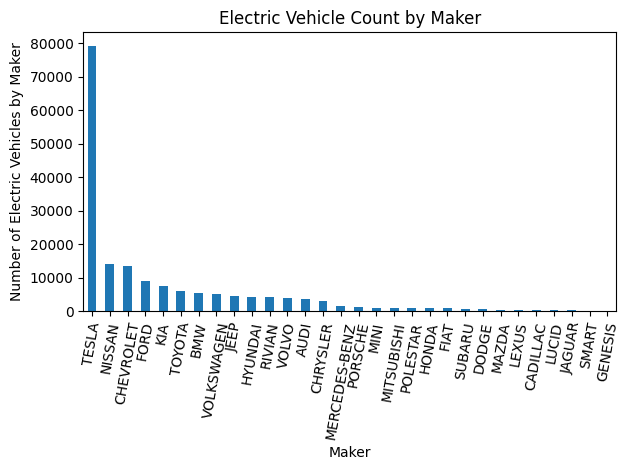

In [ ]:
combined_electric_vehicle_df['make'].value_counts().plot(kind='bar')
plt.title('Electric Vehicle Count by Maker')
plt.xticks(rotation=80)
plt.xlabel("Maker")
plt.ylabel("Number of Electric Vehicles by Maker")
plt.tight_layout()

plt.show()

### Electric Vehicles by Type

Battery electric vehicles vs plug-in hybrid vehicle types. Battery electric vehicles make up more than 75% of the market verus plug-in hybrids.

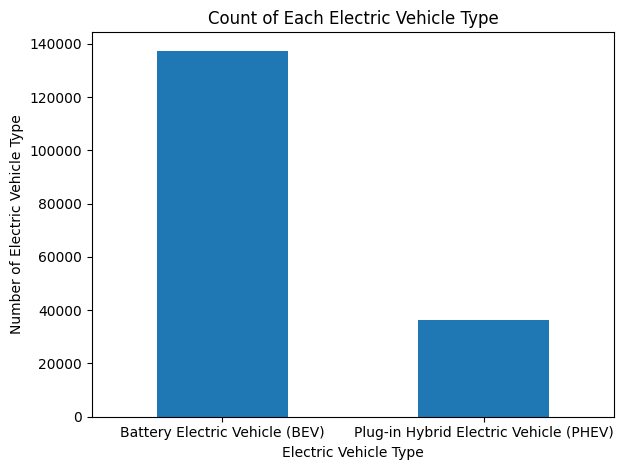

In [ ]:
combined_electric_vehicle_df['electric_vehicle_type'].value_counts().plot(kind='bar')
plt.title('Count of Each Electric Vehicle Type')
plt.xlabel("Electric Vehicle Type")
plt.ylabel("Number of Electric Vehicle Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Electric Vehicles by CAFV Eligibility

Here we find that most of our data is unknown, however more vehicles are eligible for clean alternative fuel than are not eligible.

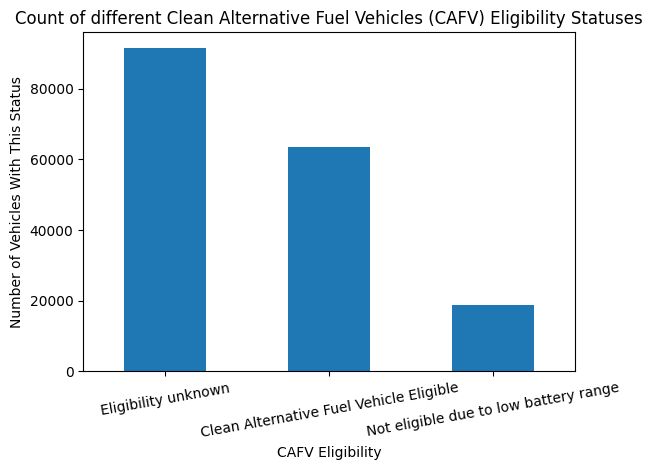

In [ ]:
combined_electric_vehicle_df['cafv_eligibility'].value_counts().plot(kind='bar')

ax = combined_electric_vehicle_df['cafv_eligibility'].value_counts().plot(kind='bar')
xticks = plt.gca().get_xticklabels()
xticks[0].set_text("Eligibility unknown")
ax.set_xticklabels(xticks)

plt.title('Count of different Clean Alternative Fuel Vehicles (CAFV) Eligibility Statuses')
plt.xlabel("CAFV Eligibility")
plt.ylabel("Number of Vehicles With This Status")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

### Electric Vehicles by Gross Income
Number of electric vehicles by gross income. There is a strong correlation between gross income and the number of electric vehicles.

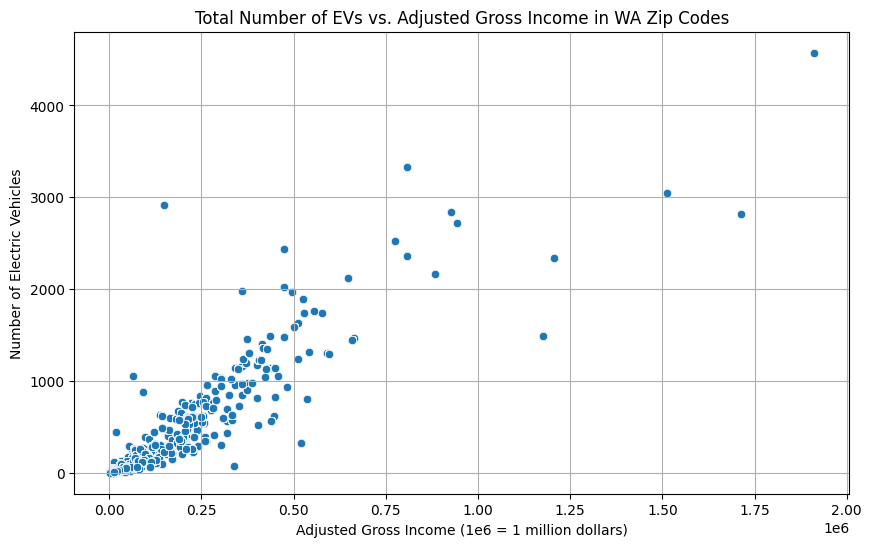

Correlation coefficient: 0.8531880166267735


In [ ]:
# plot EV Count vs income
plt.figure(figsize=(10, 6))
sns.scatterplot(x='adjust_gross_income', y='number_of_electric_vehicles_by_zip', data=correlation_df)
plt.title('Total Number of EVs vs. Adjusted Gross Income in WA Zip Codes')
plt.xlabel('Adjusted Gross Income (1e6 = 1 million dollars)')
plt.ylabel('Number of Electric Vehicles')
plt.grid(True)
plt.show()

correlation_income = correlation_df['adjust_gross_income'].corr(correlation_df['number_of_electric_vehicles_by_zip'])
print(f"Correlation coefficient: {correlation_income}")

We can already see there is a linear relationship between income and number of electric vehicles.

### Electric Vehicles by Population
The number of electric vehicles by population, and there exists a loose visual correlation between population and the number of ev's.

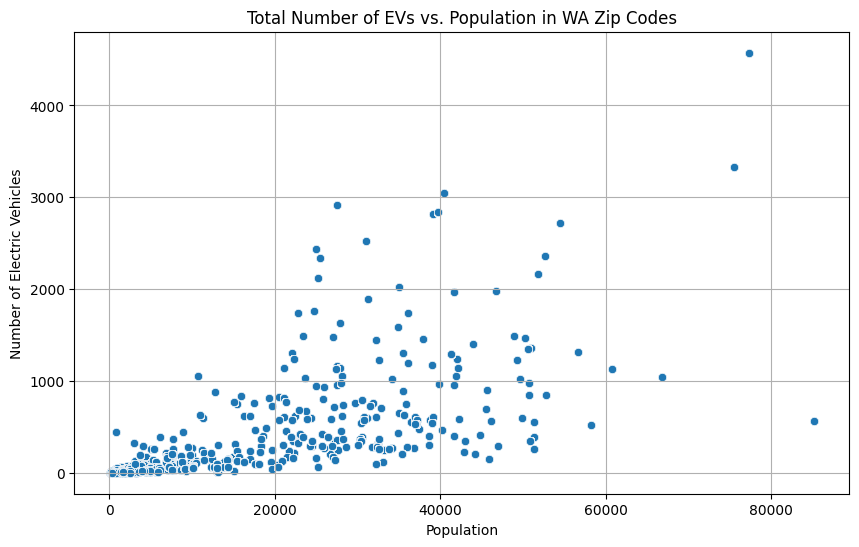

Correlation coefficient: 0.599268061501115


In [ ]:
# plot EV Count vs population
plt.figure(figsize=(10, 6))
sns.scatterplot(x='population_of_zip_code', y='number_of_electric_vehicles_by_zip', data=correlation_df)
plt.title('Total Number of EVs vs. Population in WA Zip Codes')
plt.xlabel('Population')
plt.ylabel('Number of Electric Vehicles')
plt.grid(True)
plt.show()

correlation_population = correlation_df['population_of_zip_code'].corr(correlation_df['number_of_electric_vehicles_by_zip'])
print(f"Correlation coefficient: {correlation_population}")

### Electric Vehicles by Charging Stations
Plotting the number of electric vehicles by the number of charging stations. Very litte visual correlation in this data.

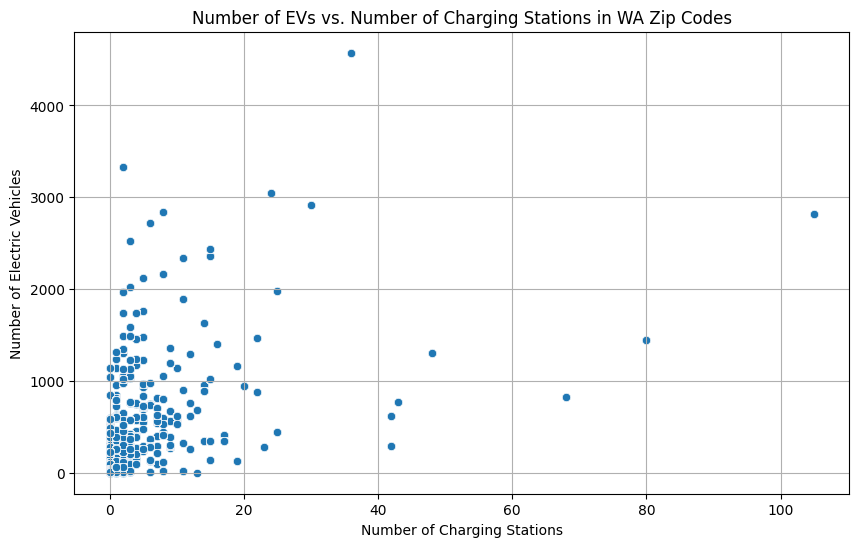

Correlation coefficient: 0.40231377863994283


In [ ]:
# Plot EV Count vs. number of charging stations
plt.figure(figsize=(10, 6))
sns.scatterplot(x='number_of_charging_stations', y='number_of_electric_vehicles_by_zip', data=correlation_df)
plt.title('Number of EVs vs. Number of Charging Stations in WA Zip Codes')
plt.xlabel('Number of Charging Stations')
plt.ylabel('Number of Electric Vehicles')
plt.grid(True)
plt.show()

correlation_charging = correlation_df['number_of_charging_stations'].corr(correlation_df['number_of_electric_vehicles_by_zip'])
print(f"Correlation coefficient: {correlation_charging}")

### Electric Vehicles by Residential Electricity Rates
The number of electric vehicles plotted by residential electricity rates. Not much correlation can be found between the cost of residential electricity and the number of electric vehicles.

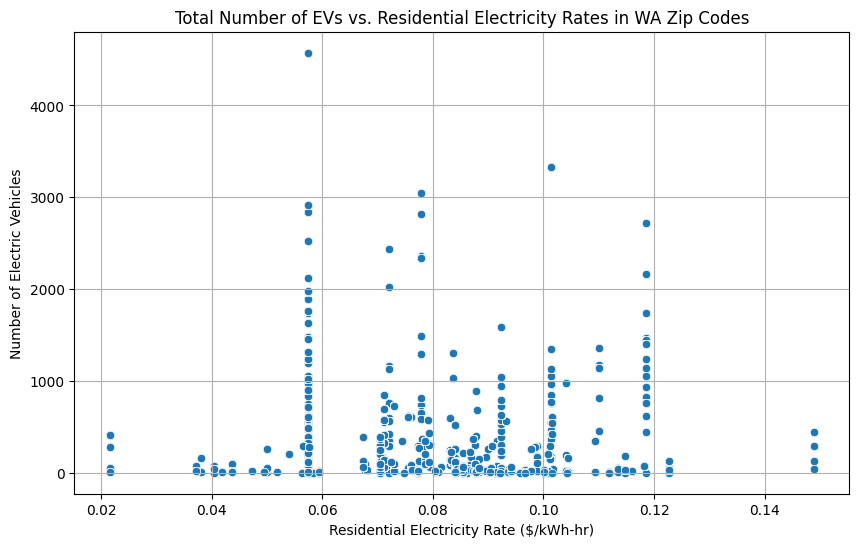

Correlation coefficient: -0.11405338404782395


In [ ]:
# plot EV Count vs Residential Electricity Rates
plt.figure(figsize=(10, 6))
sns.scatterplot(x='residential_electricity_rate', y='number_of_electric_vehicles_by_zip', data=correlation_df)
plt.title('Total Number of EVs vs. Residential Electricity Rates in WA Zip Codes')
plt.xlabel('Residential Electricity Rate ($/kWh-hr)')
plt.ylabel('Number of Electric Vehicles')
plt.grid(True)
plt.show()

correlation_electricity = correlation_df['residential_electricity_rate'].corr(correlation_df['number_of_electric_vehicles_by_zip'])
print(f"Correlation coefficient: {correlation_electricity}")

### Electric Vehicles by Model Year

The model year of the vehicle has no correlation with the number of electric vehicles overall.

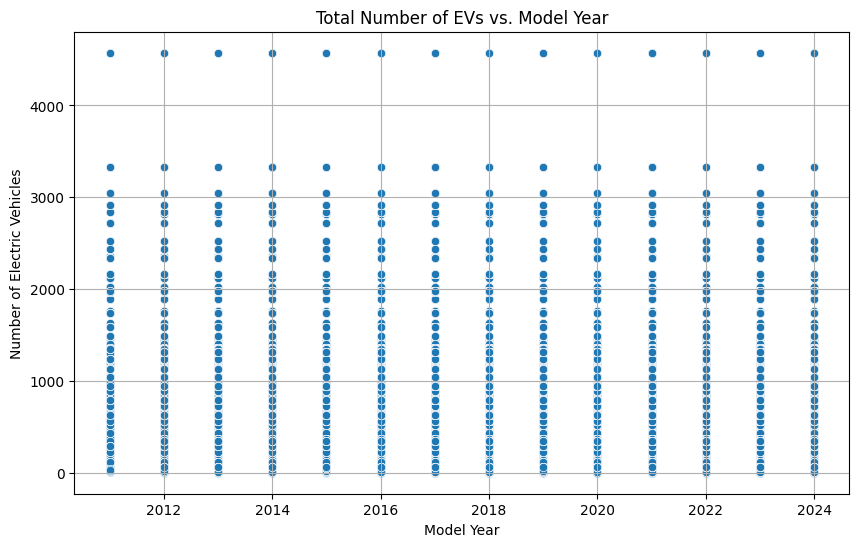

Correlation coefficient: 0.08866031379354683


In [ ]:
# plot EV Count vs model year

plt.figure(figsize=(10, 6))
sns.scatterplot(x='model_year', y='number_of_electric_vehicles_by_zip', data=correlation_df)
plt.title('Total Number of EVs vs. Model Year')
plt.xlabel('Model Year')
plt.ylabel('Number of Electric Vehicles')
plt.grid(True)
plt.show()

correlation_year = correlation_df['model_year'].corr(correlation_df['number_of_electric_vehicles_by_zip'])
print(f"Correlation coefficient: {correlation_year}")

### Correlation Heatmap of Numerical Features

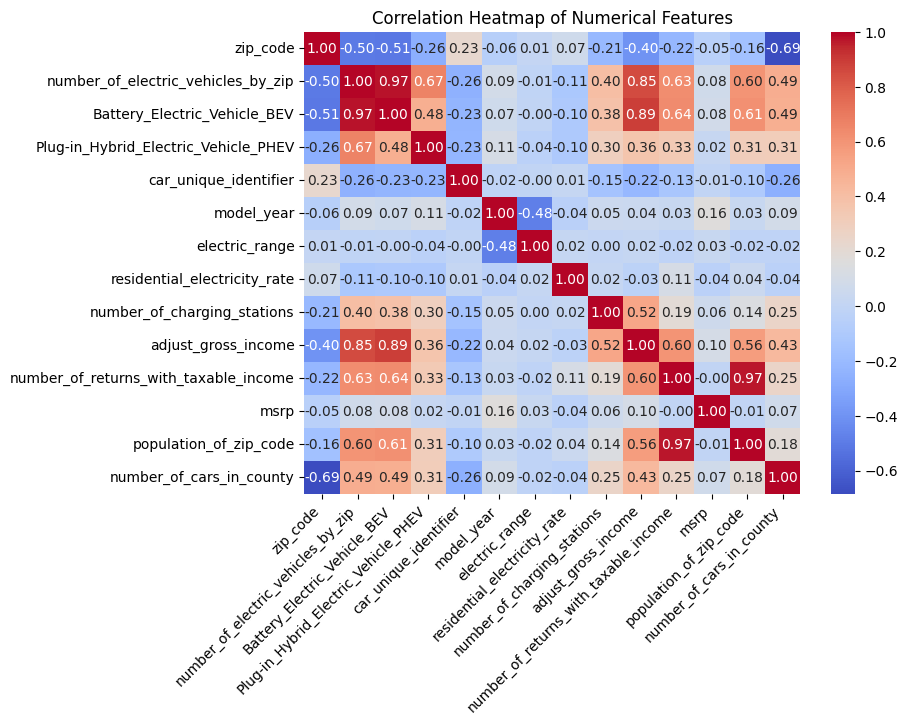

In [ ]:
# Correlation Heatmap
numerical_cols = correlation_df.select_dtypes(include=np.number)
correlation_data = numerical_cols.corr()
plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(correlation_data, annot=True, cmap='coolwarm', fmt=".2f")
heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, ha='right')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Correlation Heapmap of Relevant Subset of Numerical Features

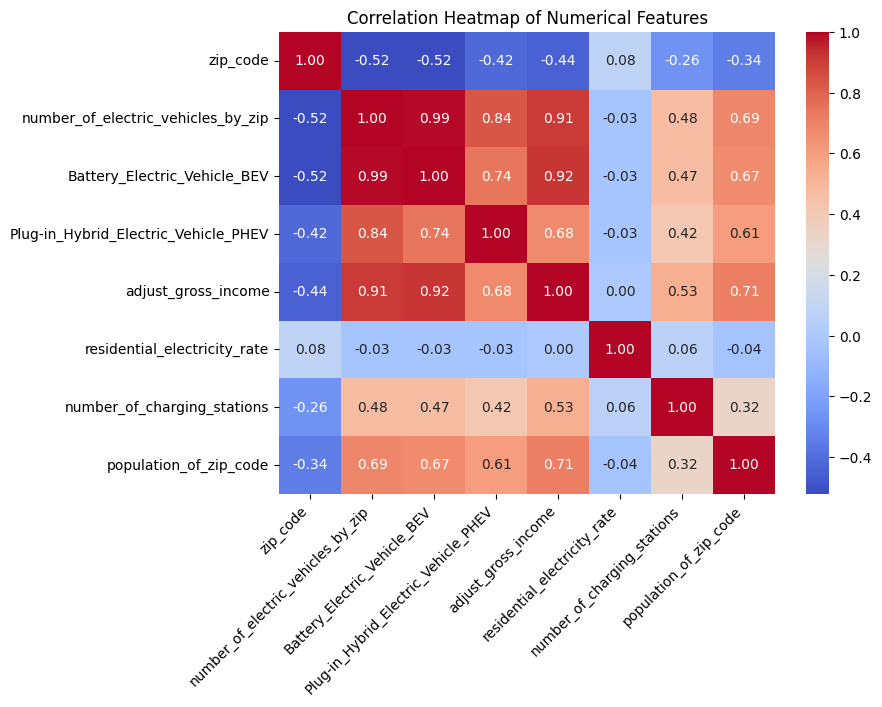

In [ ]:
# Correlation Heatmap of pairplot data
correlation_data = pairplot_df.corr()
plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(correlation_data, annot=True, cmap='coolwarm', fmt=".2f")
heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, ha='right')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

We can see the correlation between number of electric vehicles and income. It looks like there is an even larger correlation between battery electric vehicles and income. While there is also a correlation between population and number of electric vehicles, there is also a correlation between population and income -- indicating possible collinearity issues.

### Pair Plot of Several Features

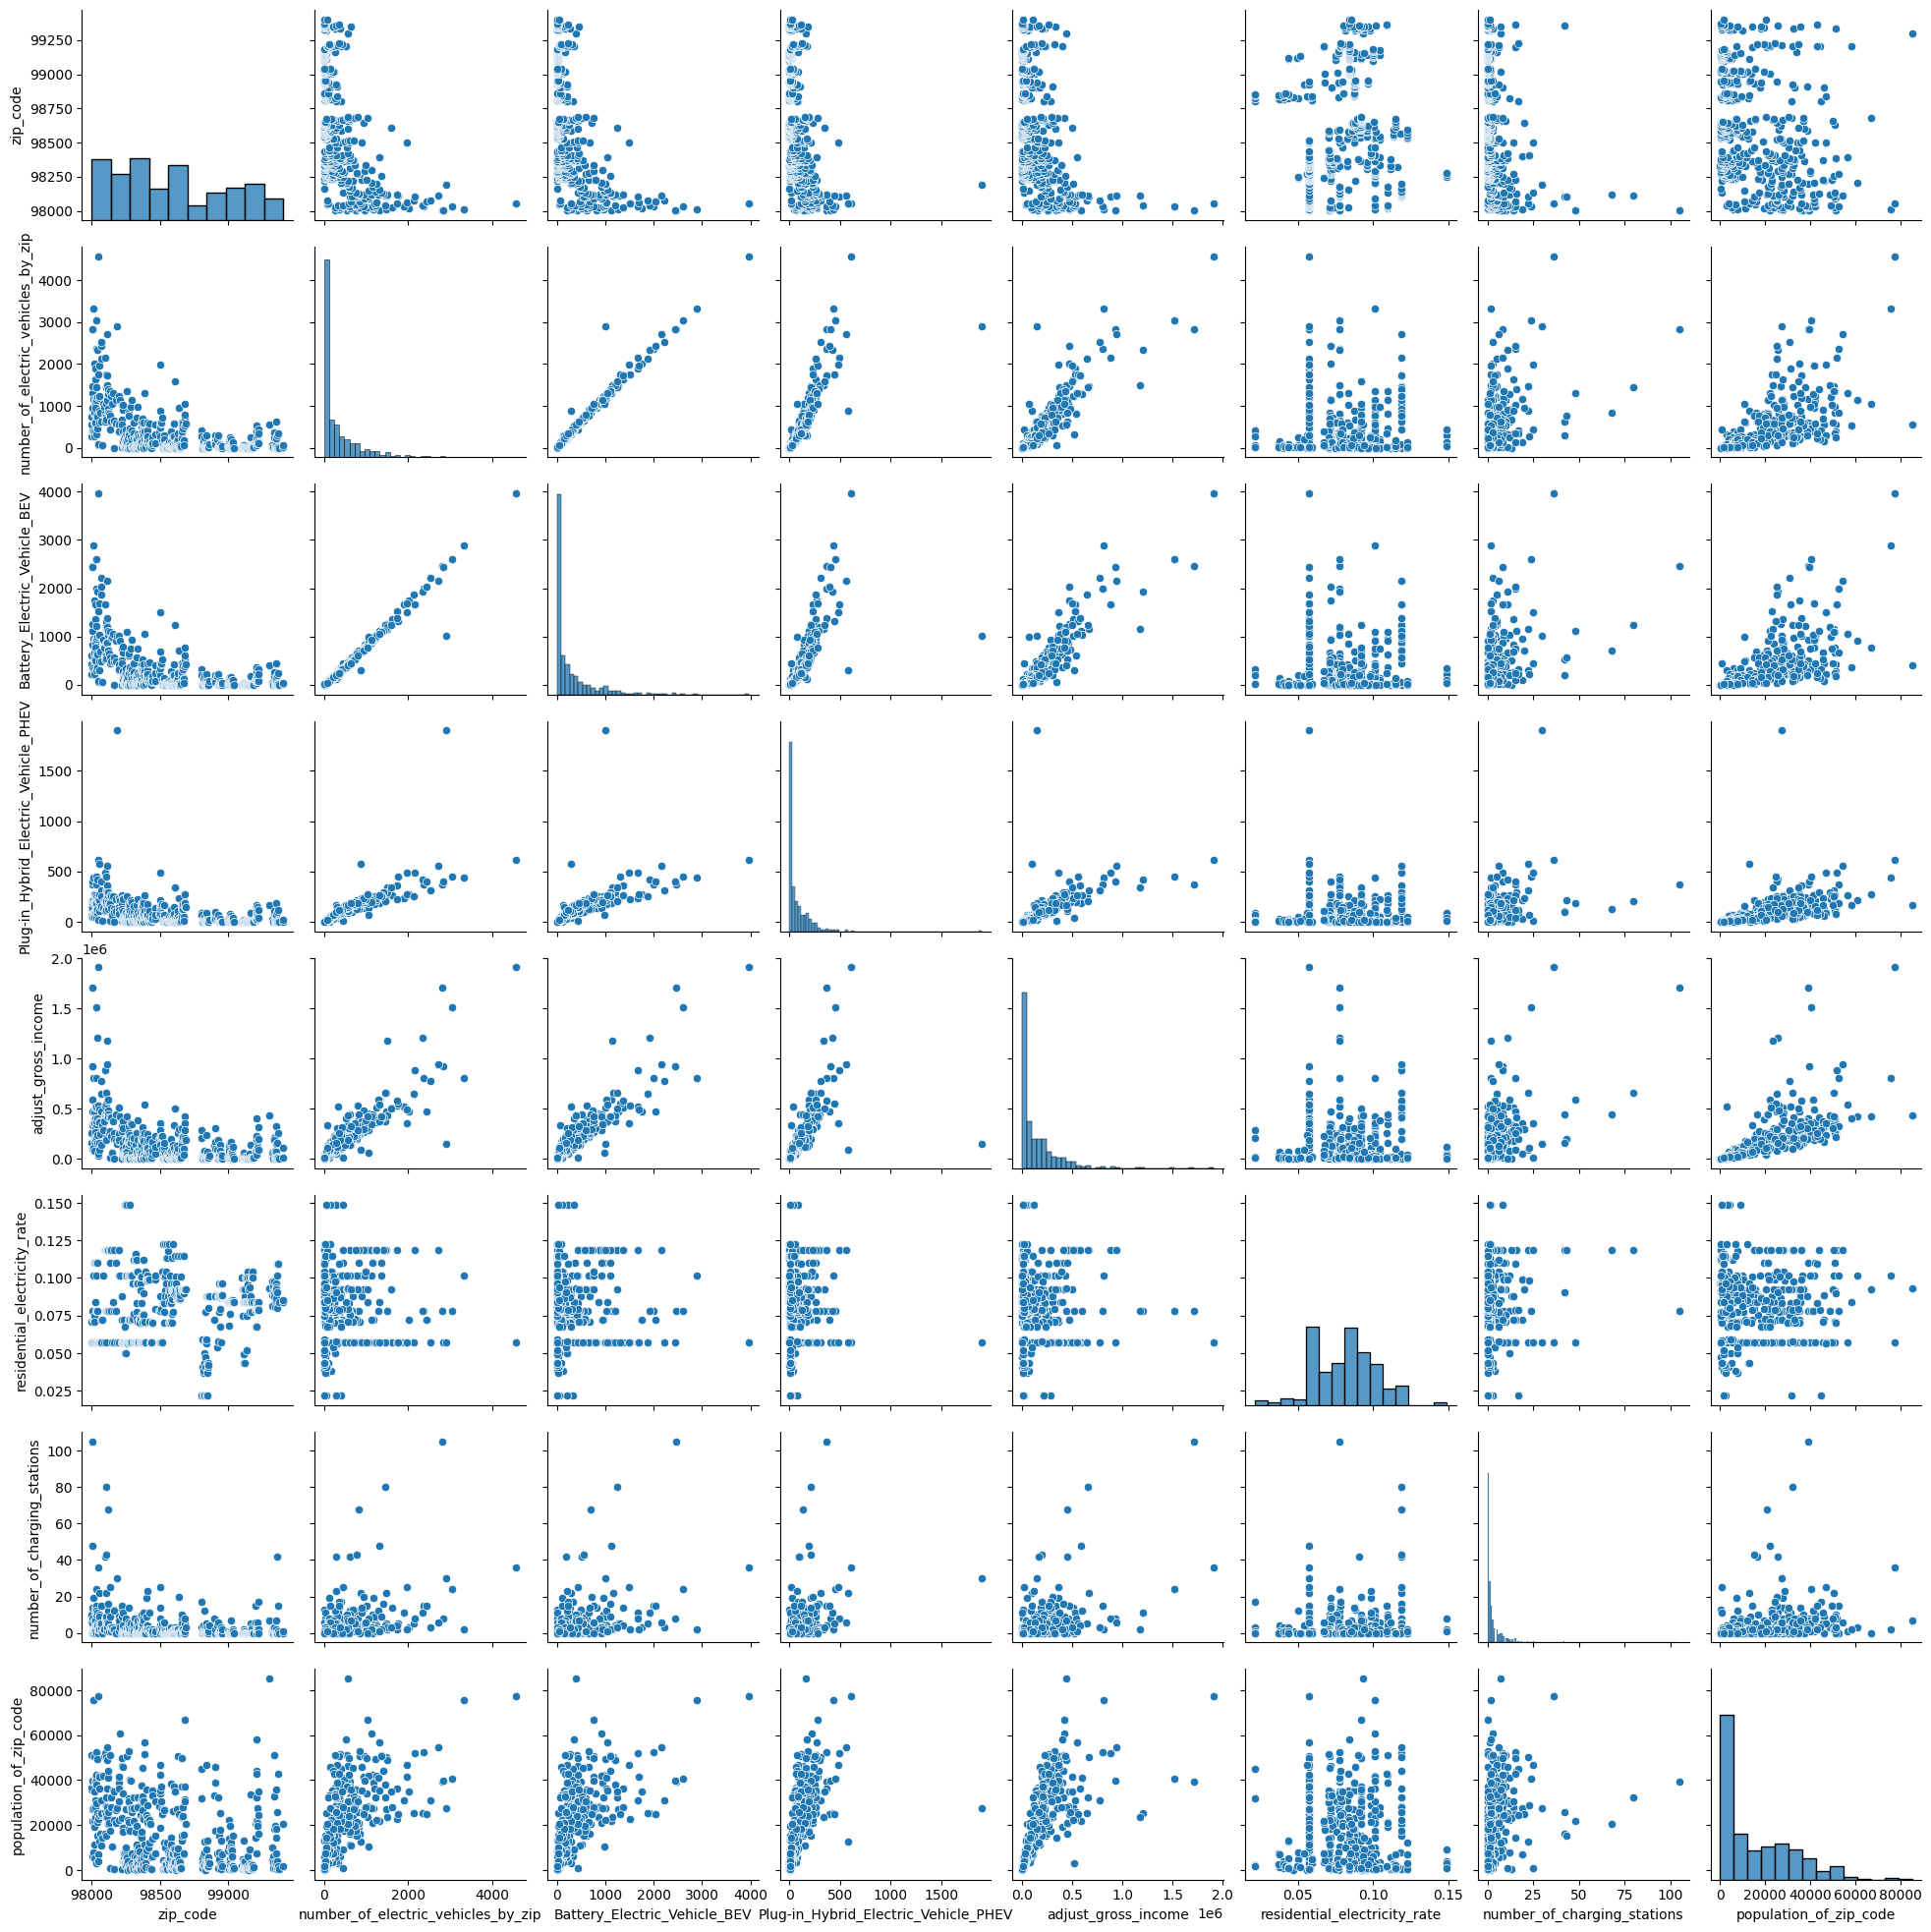

In [ ]:
sns.pairplot(pairplot_df)
plt.show()

We can see the linear relationships between income and and number of electric vehicles (as well as with number of battry electric vehicles and number of plug-in hybrids). We also see the linear relationship between population and number of EVs (and number of the two subtypes). And there does seem to be a linear relationship between income and population too.

# Modeling

Given the complexity of the data, we will take multiple approaches to modeling and understanding the relationships between the features and the number of EVs per zip code. First we we will look at smaller subsets of features, and then analyze the full feature set.

## Basic Modeling and Analysis

We first want to explore simple linear regression models based on the various pairwise correlations of certain features. In this section, we will go over some of these simple linear regressions, adding more features, and then incorporating PCA to address multicollinearity.

### Simple Linear Regression

**Feature importance for Linear Regression:**

Seeing as the plot of number of electic vehicles vs adjusted gross income in WA zip codes looks fairly linear, and since their correlation coefficient was relatively high, it makes sense to do linear regression to see how well this simple model fits.

In [ ]:
# Linear regression to demonstrate linearity between number of electric vehicles and adjusted gross income in WA zip

y = correlation_df['number_of_electric_vehicles_by_zip']
X = correlation_df['adjust_gross_income']

X = sm.add_constant(X)

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

                                    OLS Regression Results                                    
Dep. Variable:     number_of_electric_vehicles_by_zip   R-squared:                       0.728
Model:                                            OLS   Adj. R-squared:                  0.728
Method:                                 Least Squares   F-statistic:                 4.644e+05
Date:                                Sat, 07 Dec 2024   Prob (F-statistic):               0.00
Time:                                        21:23:34   Log-Likelihood:            -1.3330e+06
No. Observations:                              173571   AIC:                         2.666e+06
Df Residuals:                                  173569   BIC:                         2.666e+06
Df Model:                                           1                                         
Covariance Type:                            nonrobust                                         
                          coef    std err         

The fit from linear regression looks promising. Let's see if we can predict values just as well with this model.

In [ ]:
#Linear regression with prediction

y = correlation_df['number_of_electric_vehicles_by_zip']
X = correlation_df['adjust_gross_income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

model = sm.OLS(y_train, X_train)

results = model.fit()

print(results.summary())

y_pred = results.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print()
print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

                                    OLS Regression Results                                    
Dep. Variable:     number_of_electric_vehicles_by_zip   R-squared:                       0.727
Model:                                            OLS   Adj. R-squared:                  0.727
Method:                                 Least Squares   F-statistic:                 3.703e+05
Date:                                Sat, 07 Dec 2024   Prob (F-statistic):               0.00
Time:                                        21:23:34   Log-Likelihood:            -1.0665e+06
No. Observations:                              138856   AIC:                         2.133e+06
Df Residuals:                                  138854   BIC:                         2.133e+06
Df Model:                                           1                                         
Covariance Type:                            nonrobust                                         
                          coef    std err         

As we see from the R<sup>2</sup> value, the prediction performance is pretty good.

We see that the correlation coefficient is even higher between adjusted gross income and number of Battery Electric Vehicles -- a large subset of electric vehicles. A linear fit is even better restricting our y value to BEVs instead of all EVs.

In [ ]:
## It's even better when we restrict it to BEVs

y = correlation_df['Battery_Electric_Vehicle_BEV']
X = correlation_df['adjust_gross_income']

X = sm.add_constant(X)

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

                                 OLS Regression Results                                 
Dep. Variable:     Battery_Electric_Vehicle_BEV   R-squared:                       0.797
Model:                                      OLS   Adj. R-squared:                  0.797
Method:                           Least Squares   F-statistic:                 6.812e+05
Date:                          Sat, 07 Dec 2024   Prob (F-statistic):               0.00
Time:                                  21:23:34   Log-Likelihood:            -1.2798e+06
No. Observations:                        173571   AIC:                         2.560e+06
Df Residuals:                            173569   BIC:                         2.560e+06
Df Model:                                     1                                         
Covariance Type:                      nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------

This linear model works well for prediction as well.

In [ ]:
# Linear regression with prediction for BEVs

y = correlation_df['Battery_Electric_Vehicle_BEV']
X = correlation_df['adjust_gross_income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

model = sm.OLS(y_train, X_train)

results = model.fit()

print(results.summary())

y_pred = results.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print()
print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

                                 OLS Regression Results                                 
Dep. Variable:     Battery_Electric_Vehicle_BEV   R-squared:                       0.797
Model:                                      OLS   Adj. R-squared:                  0.797
Method:                           Least Squares   F-statistic:                 5.437e+05
Date:                          Sat, 07 Dec 2024   Prob (F-statistic):               0.00
Time:                                  21:23:34   Log-Likelihood:            -1.0239e+06
No. Observations:                        138856   AIC:                         2.048e+06
Df Residuals:                            138854   BIC:                         2.048e+06
Df Model:                                     1                                         
Covariance Type:                      nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------

To make sure the predictions really are that good, let's do k-fold validation with k = 5. We see that it has more or less the same prediction performance every time.

In [ ]:
# Doing K-fold validation on BEV vs income to make sure it's not a fluke

y = correlation_df['Battery_Electric_Vehicle_BEV']
X = correlation_df['adjust_gross_income']

X = sm.add_constant(X)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mse_list = []
r2_list = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = sm.OLS(y_train, X_train)
    results = model.fit()

    y_pred = results.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    mse_list.append(mse)
    r2_list.append(r2)
    print(f"Mean Squared Error: {mse}")
    print(f"R² Score: {r2}")

avg_mse = np.mean(mse_list)
avg_r2 = np.mean(r2_list)

print()
print(f"Average Mean Squared Error: {avg_mse}")
print(f"Average R² Score: {avg_r2}")

Mean Squared Error: 147972.62675575583
R² Score: 0.7983725523494063
Mean Squared Error: 147531.95548083345
R² Score: 0.7986246549748082
Mean Squared Error: 149698.06482963313
R² Score: 0.7941955485167553
Mean Squared Error: 149889.97506279845
R² Score: 0.7960601180632095
Mean Squared Error: 147494.70003277843
R² Score: 0.7973901411889257

Average Mean Squared Error: 148517.46443235985
Average R² Score: 0.7969286030186209


Let's add more of the features to our linear model. The R<sup>2</sup> value does improve slightly, but it's at the expense of introducing multicollinearity, as the summary of the model shows.

                                    OLS Regression Results                                    
Dep. Variable:     number_of_electric_vehicles_by_zip   R-squared:                       0.762
Model:                                            OLS   Adj. R-squared:                  0.762
Method:                                 Least Squares   F-statistic:                 7.946e+04
Date:                                Sat, 07 Dec 2024   Prob (F-statistic):               0.00
Time:                                        21:23:35   Log-Likelihood:            -1.3213e+06
No. Observations:                              173571   AIC:                         2.643e+06
Df Residuals:                                  173563   BIC:                         2.643e+06
Df Model:                                           7                                         
Covariance Type:                            nonrobust                                         
                                   coef    std err

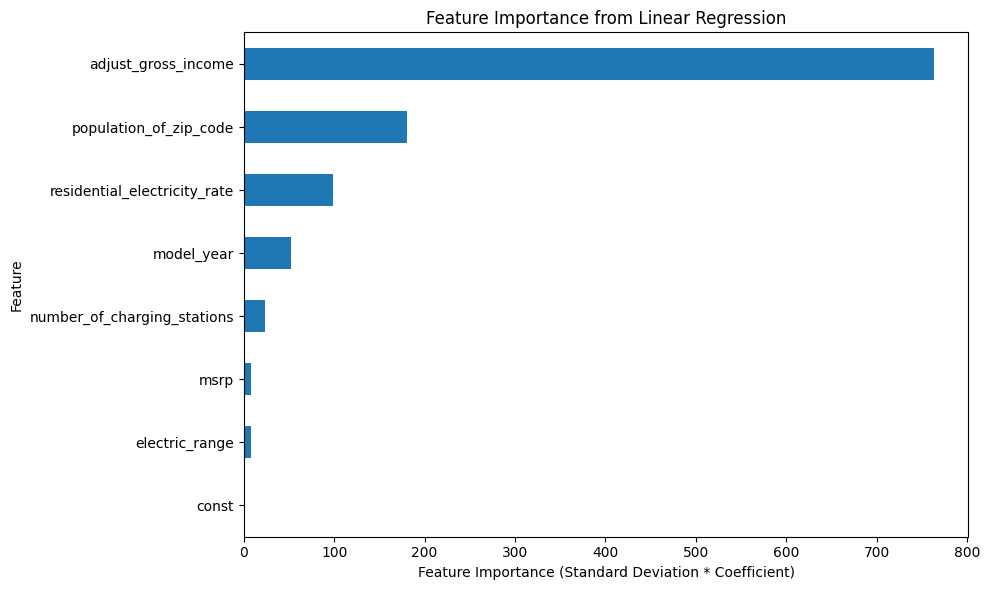

In [ ]:
# Linear regression with more features.
# Adding other features helps a little, but introduces multicollinearity

features = ['model_year', 'electric_range', 'residential_electricity_rate', 'number_of_charging_stations', 'adjust_gross_income', 'population_of_zip_code', 'msrp']

X = correlation_df[features]
y = correlation_df['number_of_electric_vehicles_by_zip']

X = sm.add_constant(X)

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

# Calculate feature importance
# Need to multiply by standard deviation for importance since StandardScaler was not used
feature_importance = X.std() * results.params.abs()

print()
print('Standard Deviation of Features')
print(X.std())
print()

plt.figure(figsize=(10, 6))
feature_importance.sort_values().plot(kind='barh')
plt.xlabel("Feature Importance (Standard Deviation * Coefficient)")
plt.ylabel("Feature")
plt.title("Feature Importance from Linear Regression")
plt.tight_layout()
plt.show()

Next let's try introducing more features to the linear model for BEVs, which had better base performance. Again, the R<sup>2</sup> value improves slightly over the simpler model using just income, but it's at the expense of introducing multicollinearity.

                                 OLS Regression Results                                 
Dep. Variable:     Battery_Electric_Vehicle_BEV   R-squared:                       0.828
Model:                                      OLS   Adj. R-squared:                  0.828
Method:                           Least Squares   F-statistic:                 1.196e+05
Date:                          Sat, 07 Dec 2024   Prob (F-statistic):               0.00
Time:                                  21:23:35   Log-Likelihood:            -1.2652e+06
No. Observations:                        173571   AIC:                         2.530e+06
Df Residuals:                            173563   BIC:                         2.531e+06
Df Model:                                     7                                         
Covariance Type:                      nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------

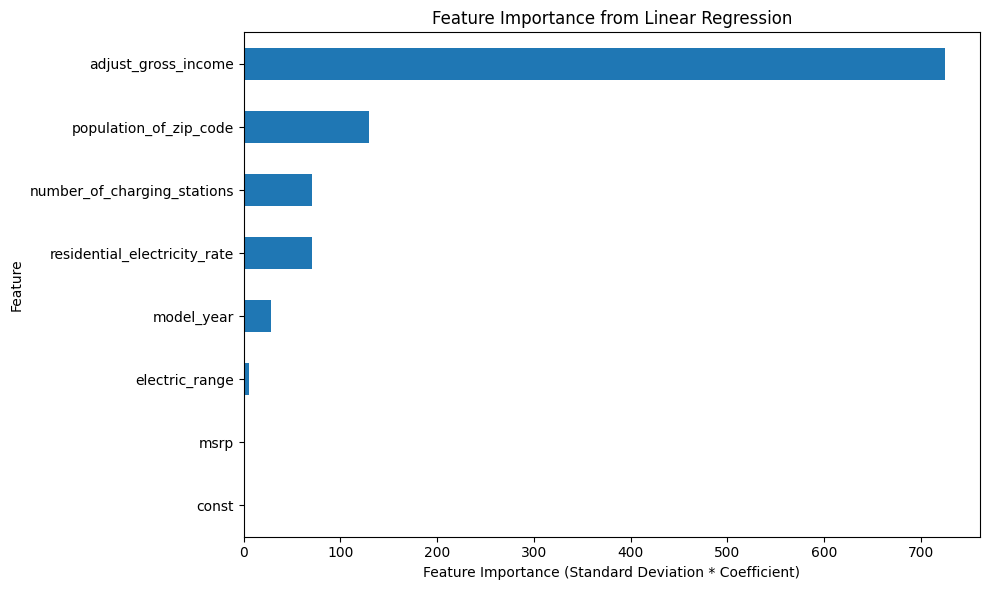

In [ ]:
# Same as above but just for BEVs

features = ['model_year', 'electric_range', 'residential_electricity_rate', 'number_of_charging_stations', 'adjust_gross_income', 'population_of_zip_code', 'msrp']

X = correlation_df[features]
y = correlation_df['Battery_Electric_Vehicle_BEV']

X = sm.add_constant(X)

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

# Calculate feature importance
# Need to multiply by standard deviation for importance since StandardScaler was not used
feature_importance = X.std() * results.params.abs()

print()
print('Standard Deviation of Features')
print(X.std())
print()

plt.figure(figsize=(10, 6))
feature_importance.sort_values().plot(kind='barh')
plt.xlabel("Feature Importance (Standard Deviation * Coefficient)")
plt.ylabel("Feature")
plt.title("Feature Importance from Linear Regression")
plt.tight_layout()
plt.show()

Even only using the top three important features (adjust_gross_income, population_of_zipcode, and number_of_charging_stations), you get nearly the same improvement in R<sup>2</sup> as when fitting to more features, and the multicollinearity is still present. Intuitively, we expect some collinearity between income and population, and if we look back at the correlation heatmap we see they have some correlation. Additionally, the pairplot shows a rough linear relationship between them.

                                    OLS Regression Results                                    
Dep. Variable:     number_of_electric_vehicles_by_zip   R-squared:                       0.760
Model:                                            OLS   Adj. R-squared:                  0.760
Method:                                 Least Squares   F-statistic:                 1.828e+05
Date:                                Sat, 07 Dec 2024   Prob (F-statistic):               0.00
Time:                                        21:23:36   Log-Likelihood:            -1.3223e+06
No. Observations:                              173571   AIC:                         2.645e+06
Df Residuals:                                  173567   BIC:                         2.645e+06
Df Model:                                           3                                         
Covariance Type:                            nonrobust                                         
                                   coef    std err

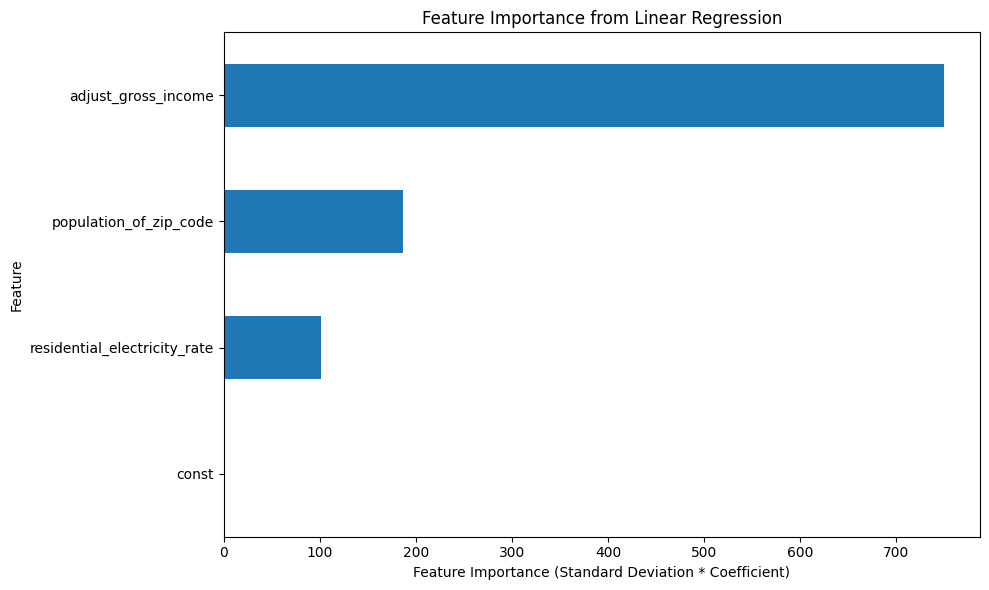

In [ ]:
# Just using the top three features. There's still a lot of multicollinearity.

features = ['residential_electricity_rate', 'adjust_gross_income', 'population_of_zip_code']

X = correlation_df[features]
y = correlation_df['number_of_electric_vehicles_by_zip']

X = sm.add_constant(X)

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

# Calculate feature importance
# Need to multiply by standard deviation for importance since StandardScaler was not used
feature_importance = X.std() * results.params.abs()

print()
print('Standard Deviation of Features')
print(X.std())
print()

plt.figure(figsize=(10, 6))
feature_importance.sort_values().plot(kind='barh')
plt.xlabel("Feature Importance (Standard Deviation * Coefficient)")
plt.ylabel("Feature")
plt.title("Feature Importance from Linear Regression")
plt.tight_layout()
plt.show()

We can perform the same linear regression on the same top three features except for just number of BEVs instead of number of all EVs. Again, the fit is just about the same as using all the features, but the multicollinearity is still present.

                                 OLS Regression Results                                 
Dep. Variable:     Battery_Electric_Vehicle_BEV   R-squared:                       0.823
Model:                                      OLS   Adj. R-squared:                  0.823
Method:                           Least Squares   F-statistic:                 2.685e+05
Date:                          Sat, 07 Dec 2024   Prob (F-statistic):               0.00
Time:                                  21:23:36   Log-Likelihood:            -1.2680e+06
No. Observations:                        173571   AIC:                         2.536e+06
Df Residuals:                            173567   BIC:                         2.536e+06
Df Model:                                     3                                         
Covariance Type:                      nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------

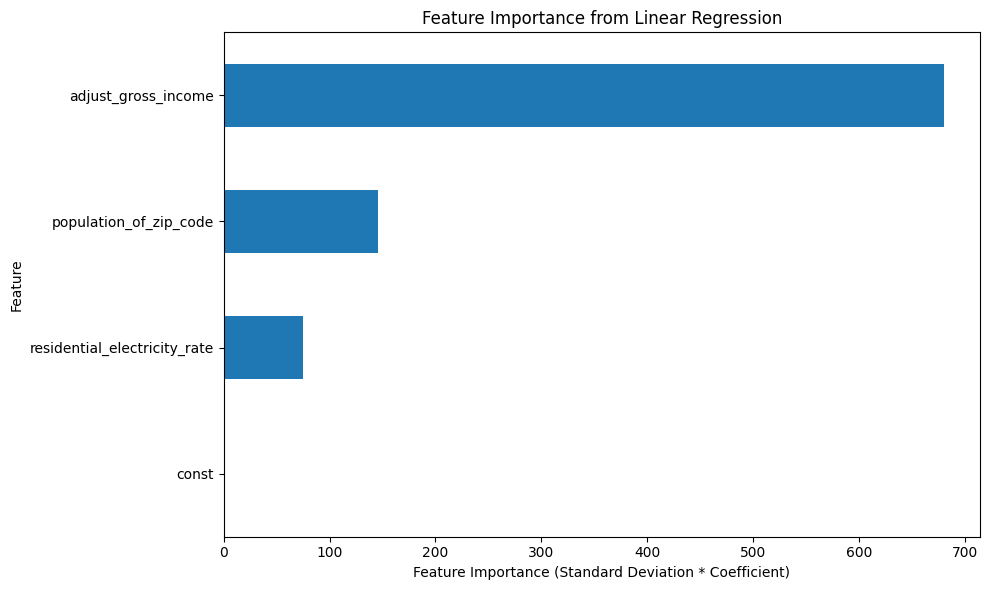

In [ ]:
# Top three features, but just for BEVs

features = ['residential_electricity_rate', 'adjust_gross_income', 'population_of_zip_code']

X = correlation_df[features]
y = correlation_df['Battery_Electric_Vehicle_BEV']

X = sm.add_constant(X)

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

# Calculate feature importance
# Need to multiply by standard deviation for importance since StandardScaler was not used
feature_importance = X.std() * results.params.abs()

print()
print('Standard Deviation of Features')
print(X.std())
print()

plt.figure(figsize=(10, 6))
feature_importance.sort_values().plot(kind='barh')
plt.xlabel("Feature Importance (Standard Deviation * Coefficient)")
plt.ylabel("Feature")
plt.title("Feature Importance from Linear Regression")
plt.tight_layout()
plt.show()

#### Incorporating PCA to Address Multicollinearity

Since there is multicollinearity in the three feature model, we will implement PCA to address it. This fit is slightly better than using income alone, but whether that slightly better fit warrants this more complex model is debatable. Our R<sup>2</sup> only went up from 0.7305 to 0.762.


In [ ]:
# Starting work on PCA

features = ['residential_electricity_rate', 'adjust_gross_income', 'population_of_zip_code']

X = correlation_df[features]
y = correlation_df['number_of_electric_vehicles_by_zip']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

print("Explained Variance by Each Component:", explained_variance)
print("Cumulative Variance:", cumulative_variance)
print()

components = pca.components_
components_df = pd.DataFrame(components, columns=features)

# Regression coefficients
pc_coefficients = model.coef_

# Display the coefficients for each PC
for i, coef in enumerate(pc_coefficients):
    print(f"Coefficient for PC{i + 1}: {coef}")

var_and_coeff_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Regression Coefficient': model.coef_,
    'Explained Variance': explained_variance,
})

print()
print("Variance and Coefficient of Each Principal Component:")
print(var_and_coeff_df.sort_values(by='Explained Variance', ascending=False))

print()
print("Principal Components (weights for each feature):")
print(components_df)

print()
print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

Explained Variance by Each Component: [0.52015265 0.33479629 0.14505106]
Cumulative Variance: [0.52015265 0.85494894 1.        ]

Coefficient for PC1: 659.0728620916642
Coefficient for PC2: -150.61246485306248
Coefficient for PC3: -386.52239018819193

Variance and Coefficient of Each Principal Component:
    PC  Regression Coefficient  Explained Variance
0  PC1              659.072862            0.520153
1  PC2             -150.612465            0.334796
2  PC3             -386.522390            0.145051

Principal Components (weights for each feature):
   residential_electricity_rate  adjust_gross_income  population_of_zip_code
0                      0.020395             0.706302                0.707617
1                      0.995725            -0.078126                0.049282
2                     -0.090091            -0.703586                0.704876

Mean Squared Error: 240611.75854051186
R² Score: 0.7620429179218392


We can perform the same PCA analysis with just BEVs to address the multicollinearity issue. Again, we improved the fit ever so slightly -- R<sup>2</sup> went from 0.798 to 0.824. However, this still does not fully address the question of if the increased performance warrants the extra complexity.

In [ ]:
# PCA with BEV as y

features = ['residential_electricity_rate', 'adjust_gross_income', 'population_of_zip_code']

X = correlation_df[features]
y = correlation_df['Battery_Electric_Vehicle_BEV']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

print("Explained Variance by Each Component:", explained_variance)
print("Cumulative Variance:", cumulative_variance)
print()

components = pca.components_
components_df = pd.DataFrame(components, columns=features)

# Regression coefficients
pc_coefficients = model.coef_

# Display the coefficients for each PC
for i, coef in enumerate(pc_coefficients):
    print(f"Coefficient for PC{i + 1}: {coef}")

var_and_coeff_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Regression Coefficient': model.coef_,
    'Explained Variance': explained_variance,
})

print()
print("Variance and Coefficient of Each Principal Component:")
print(var_and_coeff_df.sort_values(by='Explained Variance', ascending=False))

print()
print("Principal Components (weights for each feature):")
print(components_df)

print()
print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

Explained Variance by Each Component: [0.52015265 0.33479629 0.14505106]
Cumulative Variance: [0.52015265 0.85494894 1.        ]

Coefficient for PC1: 581.6838937773853
Coefficient for PC2: -120.53997455150181
Coefficient for PC3: -368.72291897055277

Variance and Coefficient of Each Principal Component:
    PC  Regression Coefficient  Explained Variance
0  PC1              581.683894            0.520153
1  PC2             -120.539975            0.334796
2  PC3             -368.722919            0.145051

Principal Components (weights for each feature):
   residential_electricity_rate  adjust_gross_income  population_of_zip_code
0                      0.020395             0.706302                0.707617
1                      0.995725            -0.078126                0.049282
2                     -0.090091            -0.703586                0.704876

Mean Squared Error: 129142.91085567448
R² Score: 0.8240299164184098


Both PCA analyses for number of EVs and number of BEVs lead to very similar results. In both cases the first principal component consists mostly of roughly $\sqrt{2} \over 2 $ parts income and $\sqrt{2} \over 2 $ parts population. The second principal component consists mostly of electricity rate, and the third principal component consists mostly of roughly -$\sqrt{2} \over 2 $ parts income and $\sqrt{2} \over 2 $ parts population. Since the coefficient for that third principal component is negative, the net effect is to subtract out some of the effect of population. Looking at the sizes of the coefficients, it's clear that we once again have a model that is mostly based on income, with a little bit of population added in, and a little less electricity rate. Only the collinearity issue has been removed.

It's hard to justify this considerably more complex model for the slight improvement in fit. So far the conclusion seems to be that the higher the income in a zip code, the more electric vehicles (and the more battery electric vehicles) in the zip code.

Now let's try Lasso and Ridge, and see if penalizing the parameter training improves the performance.

#### Ridge Regression on BEVs with limited feature set

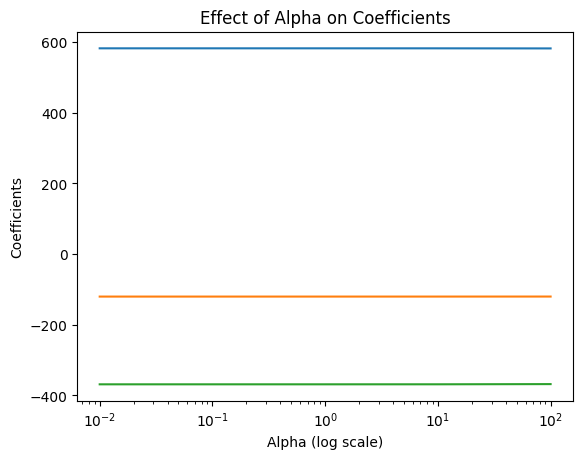

In [ ]:
#visualize alpha and coefficient
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

alphas = [0.01, 0.1, 1, 10, 100]
coefficients = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    coefficients.append(ridge.coef_)

plt.plot(alphas, coefficients)
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficients')
plt.title('Effect of Alpha on Coefficients')
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV
# grab the best alpha to compare
# Define the range of alpha values to test
alpha_values = {'alpha': [0.01, 0.1, 1, 10, 100]}

# Ridge Regression
ridge = Ridge()
ridge_grid = GridSearchCV(estimator=ridge, param_grid=alpha_values, scoring='neg_mean_squared_error', cv=5)
ridge_grid.fit(X_train, y_train)

# Best Alpha for Ridge
print("Best Alpha for Ridge:", ridge_grid.best_params_['alpha'])
print("Best Cross-Validation Score for Ridge:", -ridge_grid.best_score_)

Best Alpha for Ridge: 0.01
Best Cross-Validation Score for Ridge: 129791.02244298012


In [ ]:
# Ridge Regression with alpha=0.01
ridge = Ridge(alpha=ridge_grid.best_params_['alpha'])
ridge.fit(X_train, y_train)

# Predict and evaluate
ridge_predictions = ridge.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_predictions)
r2 = r2_score(y_test, ridge_predictions)

print("Ridge Regression Coefficients:", ridge.coef_)
print("Ridge Regression Mean Squared Error:", ridge_mse)
print("R² Score:", r2)

Ridge Regression Coefficients: [ 581.68386688 -120.53996595 -368.72285786]
Ridge Regression Mean Squared Error: 129142.91088833944
R² Score: 0.8240299163739006


As we can see from the graph, increase alpha seemed to have a negligible effect on the parameters, and resulted in nearly exactly the same R<sup>2</sup> value. Ridge regression does not help us much with this model. This is somewhat to be expected, as Ridge regression is particularly effective when there are multiple similarly large parameters. Since we have limited to only the top three features and one is clearly larger than the other, Ridge regression is not of much use to us.

#### Lasso Regression on BEVs with limited feature set

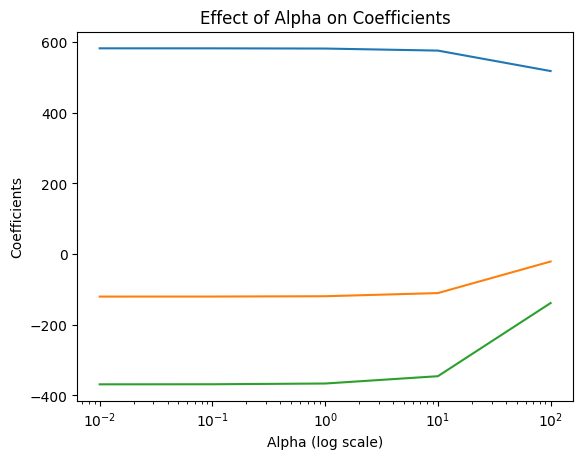

In [ ]:
# see the effects of coefficients and alpha
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

alphas = [0.01, 0.1, 1, 10, 100]
coefficients = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    coefficients.append(lasso.coef_)

plt.plot(alphas, coefficients)
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficients')
plt.title('Effect of Alpha on Coefficients')
plt.show()


In [ ]:
# find the best alpha
lasso = Lasso()
lasso_grid = GridSearchCV(estimator=lasso, param_grid=alpha_values, scoring='neg_mean_squared_error', cv=5)
lasso_grid.fit(X_train, y_train)

# Best Alpha for Lasso
print("Best Alpha for Lasso:", lasso_grid.best_params_['alpha'])
print("Best Cross-Validation Score for Lasso:", -lasso_grid.best_score_)

Best Alpha for Lasso: 0.01
Best Cross-Validation Score for Lasso: 129791.02309269414


In [ ]:
# Lasso Regression with alpha=0.1
lasso = Lasso(alpha=lasso_grid.best_params_['alpha'])
lasso.fit(X_train, y_train)

# Predict and evaluate
lasso_predictions = lasso.predict(X_test)
lasso_mse = mean_squared_error(y_test, lasso_predictions)
r2 = r2_score(y_test, lasso_predictions)

print("Lasso Regression Coefficients:", lasso.coef_)
print("Lasso Regression Mean Squared Error:", lasso_mse)
print("R² Score:", r2)

Lasso Regression Coefficients: [ 581.67746383 -120.53005148 -368.69992496]
Lasso Regression Mean Squared Error: 129142.93352584608
R² Score: 0.8240298855280422


Here we see that Lasso Regression is similarly not as effective in improving performance as we have limited parameters, resulting in a very similar R<sup>2</sup> value.

#### Elastic Net on BEVs with limited feature set
Given the need we want larger parameters and are dealing with high correlated parameters, we decide to try use Elastic Net to solve the accuracy puzzle.

In [ ]:
# using elastic net for BEVs with top few parameters
from sklearn.linear_model import ElasticNet

features = ['model_year', 'electric_range', 'residential_electricity_rate', 'number_of_charging_stations', 'adjust_gross_income', 'population_of_zip_code', 'msrp']

X = correlation_df[features]
y = correlation_df['Battery_Electric_Vehicle_BEV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply Elastic Net
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)  # alpha is the regularization strength, l1_ratio controls L1 vs L2

# Train the model
elastic_net.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = elastic_net.predict(X_test_scaled)

# 6. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Elastic Net Regression Results")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Coefficients of the model
print("Elastic Net Coefficients:")
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': elastic_net.coef_
})
print(coefficients)



Elastic Net Regression Results
Mean Squared Error (MSE): 126949.3617
R-squared (R2): 0.8270
Elastic Net Coefficients:
                        Feature  Coefficient
0                    model_year    26.769796
1                electric_range     5.206363
2  residential_electricity_rate   -70.514468
3   number_of_charging_stations   -38.982108
4           adjust_gross_income   661.110127
5        population_of_zip_code   152.890493
6                          msrp     2.602420


In [ ]:
# using elastic net for BEVs with only three parameters
from sklearn.linear_model import ElasticNet

features = ['residential_electricity_rate', 'adjust_gross_income', 'population_of_zip_code']

X = correlation_df[features]
y = correlation_df['Battery_Electric_Vehicle_BEV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply Elastic Net
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)  # alpha is the regularization strength, l1_ratio controls L1 vs L2

# Train the model
elastic_net.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = elastic_net.predict(X_test_scaled)

# 6. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Elastic Net Regression Results")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Coefficients of the model
print("Elastic Net Coefficients:")
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': elastic_net.coef_
})
print(coefficients)



Elastic Net Regression Results
Mean Squared Error (MSE): 130341.7929
R-squared (R2): 0.8224
Elastic Net Coefficients:
                        Feature  Coefficient
0  residential_electricity_rate   -73.086350
1           adjust_gross_income   639.250224
2        population_of_zip_code   160.005849


**Summary**

Elastic Net seems to improve the performance slightly with more parameters compared to just the top 3. We see similar improvement in performance from these multiple methods of resolving colliearity.

## Modeling with the full feature set

We also want to explore modeling with the full feature set, to compare the improvement (if any) and evaluate increasing model complexity as compared to model performance. With significant multicollinearity, we will first apply PCA. While we may lose some interpretability, the tradeoff may yield greater model performance.

In [ ]:
correlation_df.head()

,zip_code,number_of_electric_vehicles_by_zip,Battery_Electric_Vehicle_BEV,Plug-in_Hybrid_Electric_Vehicle_PHEV,car_unique_identifier,county,model_year,make,model,electric_vehicle_type,cafv_eligibility,electric_range,residential_electricity_rate,number_of_charging_stations,adjust_gross_income,number_of_returns_with_taxable_income,msrp,population_of_zip_code,number_of_cars_in_county
0,98001,748,609.0,139.0,9,king,2022,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,30,0.057423,6.0,260874,2565,66875,35842,5934
1,98001,748,609.0,139.0,738,king,2016,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210,0.057423,6.0,260874,2565,74990,35842,5934
2,98001,748,609.0,139.0,837,king,2022,TESLA,MODEL X,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0.057423,6.0,260874,2565,79900,35842,5934
3,98001,748,609.0,139.0,1171,king,2016,VOLKSWAGEN,E-GOLF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,83,0.057423,6.0,260874,2565,32790,35842,5934
4,98001,748,609.0,139.0,1348,king,2022,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0.057423,6.0,260874,2565,38990,35842,5934


Since our main question focuses on numbers of EVs within zipcodes, we have to drop columns that group based on county. Additionally, we need to drop the columns that have counts of BEVs and PHEVs, as these are effectively "cheating" the model by training it on the value we are trying to predict. We also remove the unique identifier for cars and one-hot encode the categorical features.

In [ ]:
# Data loading
from sklearn.model_selection import train_test_split
import pandas as pd

data = correlation_df.copy()
# Remove county columns
data = data.drop(columns=['county', 'number_of_cars_in_county'])
# Remove BEV and PHEV counts
data = data.drop(columns=['Battery_Electric_Vehicle_BEV', 'Plug-in_Hybrid_Electric_Vehicle_PHEV'])
# Remove unique identifier
data = data.drop(columns=['car_unique_identifier'])
# One-Hot Encode categorical features
categorical_columns = ['make', 'model', 'electric_vehicle_type', 'zip_code', 'cafv_eligibility']
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

# Prepare feature matrix (X) and target vector (y)
X = data.drop(columns=['number_of_electric_vehicles_by_zip'])
y = data['number_of_electric_vehicles_by_zip']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### PCA on Full Feature Set

**Run PCA**

In [ ]:
# TO-DO: Import necessary libraries
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scaling because PCA is not scale invariant
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# TO-DO: Instantiate and Fit PCA
pca = PCA()
X_pca = pca.fit(X_train_scaled)

**Plot and analyze cumulative variance**

We decided to pick components that explained 80% variance, and confirmed the number of components with the transformed data.

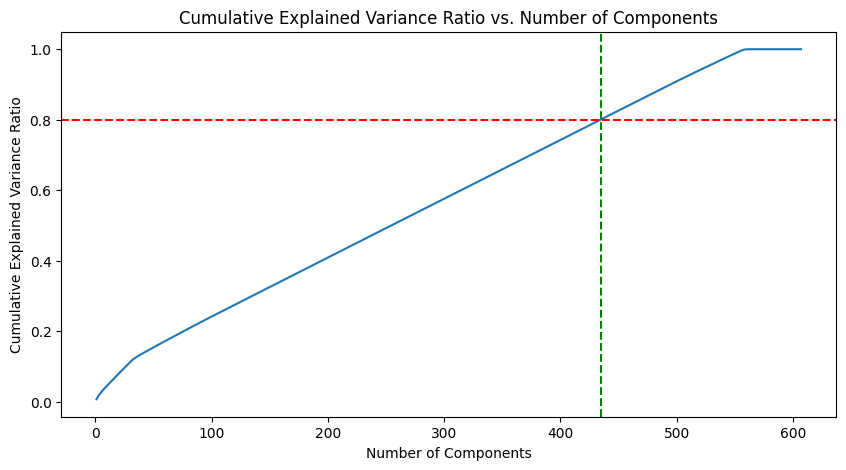

In [ ]:
explained_variance_ratios = pca.explained_variance_ratio_
cum_evr = np.cumsum(explained_variance_ratios)

fig, ax = plt.subplots(figsize=(10, 5))
n_plot = sns.lineplot(x=range(1, len(cum_evr) + 1), y=cum_evr, ax=ax)
n_plot.axhline(y = 0.8, color = 'r', linestyle = '--')
plt.xticks(range(0, len(cum_evr) + 1, 100))
n_plot.set_xlabel('Number of Components')
n_plot.set_ylabel('Cumulative Explained Variance Ratio')
n_plot.set_title('Cumulative Explained Variance Ratio vs. Number of Components')
n_plot.axvline(x = 435, color = 'g', linestyle = '--')

**Final PCA**

In [ ]:
# Refit and transform on training with parameter n
n = 0.8
pca = PCA(n_components=n)

# Fit on training set
X_train_trans = pca.fit_transform(X_train_scaled)

# Transform on test set
X_test_pca = pca.transform(X_test_scaled)

# Number of PCA components
print(f"Number of PCA components: {pca.n_components_}")

Number of PCA components: 435


### Full Feature Set Linear Regression with PCA


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Train a linear regression model
lin_reg_pca = LinearRegression()
lin_reg_pca.fit(X_train_trans, y_train)

# Make predictions
y_pred = lin_reg_pca.predict(X_test_pca)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R-Squared (R²):", r2)


Mean Squared Error (MSE): 90674.26891552085
R-Squared (R²): 0.9103261429051275


We can see that running our PCA-transformed Linear Regression on our full feature set has significantly improved performance as compared to our simpler modeling, with an R<sup>2</sup> value of 0.91. However, the downside here is that we lose some insight into what is actually affecting the model.

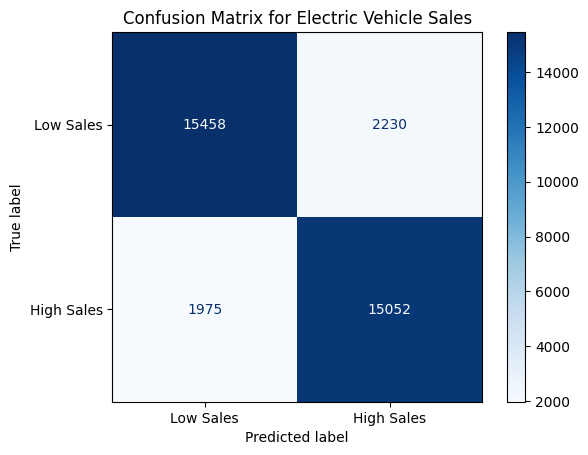

              precision    recall  f1-score   support

   Low Sales       0.89      0.87      0.88     17688
  High Sales       0.87      0.88      0.88     17027

    accuracy                           0.88     34715
   macro avg       0.88      0.88      0.88     34715
weighted avg       0.88      0.88      0.88     34715



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Define a threshold for "high sales" vs. "low sales"
threshold = median_sales = correlation_df['number_of_electric_vehicles_by_zip'].median()

# Convert actual values and predictions into binary classification
y_test_class = (y_test > threshold).astype(int)  # Actual labels
y_pred_class = (y_pred > threshold).astype(int)  # Predicted labels

# Create a confusion matrix
cm = confusion_matrix(y_test_class, y_pred_class)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Sales', 'High Sales'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Electric Vehicle Sales')
plt.show()

# Print a classification report for additional metrics
print(classification_report(y_test_class, y_pred_class, target_names=['Low Sales', 'High Sales']))

As another metric of comparison, we divide the number of EV sales into "High Sales" and "Low Sales", split by the median, and create a Confusion Matrix. As we can see, we have high precision, recall, and F1 score, indicating good model performance.

As before, let's run Ridge and Lasso Regression, followed by Elastic Net, to see if we can improve upon this base Linear model.

#### Ridge Regression

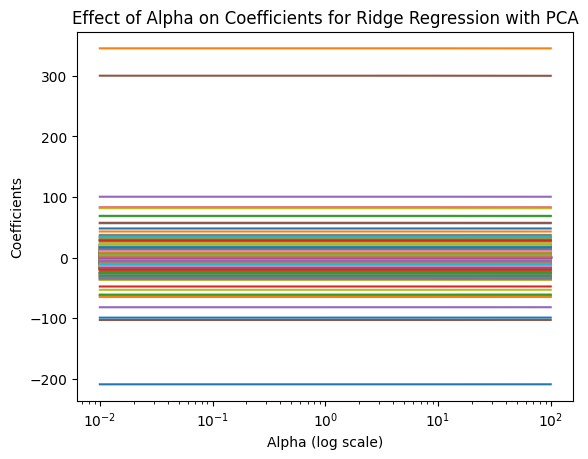

In [ ]:
# Visualize alpha and coefficient
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge

alphas = [0.01, 0.1, 1, 10, 100]
coefficients = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_trans, y_train)
    coefficients.append(ridge.coef_)

plt.plot(alphas, coefficients)
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficients')
plt.title('Effect of Alpha on Coefficients for Ridge Regression with PCA')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
# grab the best alpha to compare
# Define the range of alpha values to test
alpha_values = {'alpha': [0.01, 0.1, 1, 10, 100]}

# Ridge Regression
ridge = Ridge()
ridge_grid = GridSearchCV(estimator=ridge, param_grid=alpha_values, scoring='neg_mean_squared_error', cv=5)
ridge_grid.fit(X_train_trans, y_train)

# Best Alpha for Ridge
print("Best Alpha for Ridge:", ridge_grid.best_params_['alpha'])
print("Best Cross-Validation Score for Ridge:", -ridge_grid.best_score_)

Best Alpha for Ridge: 100
Best Cross-Validation Score for Ridge: 97045.05587786589


In [ ]:
# Ridge Regression with alpha=100
ridge = Ridge(alpha=ridge_grid.best_params_['alpha'])
ridge.fit(X_train_trans, y_train)

# Predict and evaluate
ridge_predictions = ridge.predict(X_test_pca)
ridge_mse = mean_squared_error(y_test, ridge_predictions)
r2 = r2_score(y_test, ridge_predictions)

#print("Ridge Regression Coefficients:", ridge.coef_)
print("Ridge Regression Mean Squared Error:", ridge_mse)
print("R² Score:", r2)

Ridge Regression Mean Squared Error: 90674.81329935112
R² Score: 0.9103256045274998


#### Lasso Regression

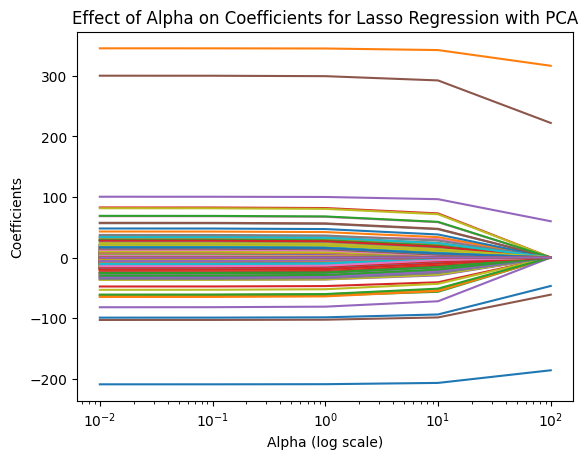

In [ ]:
# see the effects of coefficients and alpha
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

alphas = [0.01, 0.1, 1, 10, 100]
coefficients = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_trans, y_train)
    coefficients.append(lasso.coef_)

plt.plot(alphas, coefficients)
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficients')
plt.title('Effect of Alpha on Coefficients for Lasso Regression with PCA')
plt.show()

In [ ]:
# find the best alpha
lasso = Lasso()
lasso_grid = GridSearchCV(estimator=lasso, param_grid=alpha_values, scoring='neg_mean_squared_error', cv=5)
lasso_grid.fit(X_train_trans, y_train)

# Best Alpha for Lasso
print("Best Alpha for Lasso:", lasso_grid.best_params_['alpha'])
print("Best Cross-Validation Score for Lasso:", -lasso_grid.best_score_)

Best Alpha for Lasso: 1
Best Cross-Validation Score for Lasso: 94016.09183902682


In [ ]:
# Lasso Regression with alpha=1
lasso = Lasso(alpha=lasso_grid.best_params_['alpha'])
lasso.fit(X_train_trans, y_train)

# Predict and evaluate
lasso_predictions = lasso.predict(X_test_pca)
lasso_mse = mean_squared_error(y_test, lasso_predictions)
r2 = r2_score(y_test, lasso_predictions)

print("Lasso Regression Mean Squared Error:", lasso_mse)
print("R² Score:", r2)

Lasso Regression Mean Squared Error: 91061.54780285835
R² Score: 0.9099431368769089


#### Elastic Net Regression

In [ ]:
from sklearn.linear_model import ElasticNet

# Apply Elastic Net
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)  # alpha is the regularization strength, l1_ratio controls L1 vs L2

# Train the model
elastic_net.fit(X_train_trans, y_train)

# Predict on the test set
y_pred = elastic_net.predict(X_test_pca)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Elastic Net Regression Results")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")


Elastic Net Regression Results
Mean Squared Error (MSE): 91272.0002
R-squared (R2): 0.9097


**Summary**

As we saw in the Simple Linear Regression section, Ridge and Lasso did not significantly affect the features or the performance of the overall model, keeping us around R<sup>2</sup>=0.91. Elastic Net also gave us very similar performance.

# Conclusions

Through our multiple rounds of analysis, we have been able to determine many insights into the factors that affect EV sales with a zipcode in Washington. Chief among the features is adjusted gross income, which makes sense as EVs are still generally expensive relative to gas cars. Those with higher AGI likely have more disposable income to purchase a more expensive car like an EV.

We expected the number of charging stations and the residential electricity rate to have significant effects on EV sales as well, but we were surprised to see that income was much more significant than both those features. We noticed that prediction with income alone was nearly as good as when incorporating number of charging stations and residential electricity rate.

From these insights, we were able to develop a more complex predictive model incorporating additional car-specific features - including model, model year, and EV type - that had strong performance in predicting number of EVs in a zipcode.

# Challenges and Obstacles

As with many real world data analyses, this was a complex problem to tackle. Our first hurdle was collecting the data itself, choosing which information may be relevant and where to get it from. We brainstormed a variety of potential variables that would factor into EV sales, and picked datasets accordingly. With so many potential features, we ended up with a wide array of datasets to combine. One major constraint this put on us was restricting our analysis from the entire US to just the state of Washington (WA). Additionally, there was some data that no longer had a free API to access, so we had to manually scrape data such as the car MSRPs.

On the modeling side, since this was such a complex topic, we decided to apply multiple modeling techniques to determine which would be best. These different techniques had their own pros and cons, mainly regarding performance and interpretability. Additionally, our data had many sources of multicollinearity, so we had to pick our features appropriately and ensure that our PCA was properly removing this multicollinearity.

# Future Direction/What's Next

Perhaps we can try to see if we can predict which make of EV will be more likely to be purchased with the information we have. Perhaps we can see if different makes of EVs are prefered in different regions depending on other criteria. Another possibility is to investigate other data sources to see if there are other features with a predictive power on the order of income without being correlated with income.
